MODELO DE INVERSIÓN. 

PARTE I: ESTRUCTURA INICIAL.

Librerías

In [277]:
import pypsa #PyPSA: Python for Power System Analysis
import pandas as pd #Pandas: Biblioteca para manipulación y análisis de datos
import numpy as np #Numpy: Biblioteca para cálculos numéricos
import matplotlib.pyplot as plt #Matplotlib: Biblioteca para creación de gráficos
import matplotlib.dates as mdates #Matplotlib.dates: Módulo para manejar fechas en gráficos

pypsa.options.api.new_components_api = True # Activar la nueva API de componentes de PyPSA

Creación de Snapshot

In [278]:
# (1) Definir el periodo. 
hours=pd.date_range("2025-01-01", periods=24*7, freq="h") # Una semana de 2025 con resolución horaria

# (2) Crear la red vacía con esos snapshots
network=pypsa.Network()
network.set_snapshots(hours)

# (3) Calcular el peso de cada hora para extrapolar a un año completo
hours_per_year=365*24
snapshot_weight=len(hours)
single_weight=hours_per_year/snapshot_weight

#(4) Asignar el peso a cada snapshot
network.snapshot_weightings= pd.Series(single_weight,  index=network.snapshots)

# REVISAR PORQUE CREO QUE AQUÍ YA HAGO LO QUE SE HACE EN EL EXCEL CON LA HOJA SNAPSHOT ENTONCES PODRÍA OMITIRSE SI METEMOS LA HOJA DE SNAPSHOTS DEL EXCEL AQUI.

INFO:pypsa.network.index:Applying weightings to all columns of `snapshot_weightings`


In [279]:
data = pd.read_excel(
    "modelo_dispatching_españa_portugal_unido.xlsx",
    sheet_name=None,
    engine="openpyxl"
)

Lectura de Hojas de Datos (excel integrado)

In [280]:
# Verificación de correcta lectura de datos
print(data.keys())  # Muestra las hojas disponibles en el archivo Excel

dict_keys(['Guide Sheet', 'carriers', 'generators', 'buses', 'links', 'loads', 'storage_units', 'store', 'snaptshots', 'demands', 'run_of_river_inflow', 'profiles'])


In [281]:

file = "modelo_dispatching_españa_portugal_unido.xlsx"
hours_week = 168 # flexible para definir semanas
hours_year = 8760 # flexible para definir años
#---------------------------------------------------------------------------------------------------------
# Perfiles de generación renovable
df_profiles = pd.read_excel(file, sheet_name="profiles") # Leer la hoja 'profiles' del archivo Excel
df_profiles["date"] = pd.to_datetime(df_profiles["date"]) # Asegurar que la columna de fecha es datetime
    # ESPAÑA
ES_solar_profile     = df_profiles["ES_solar_profile"].iloc[:hours_week].reset_index(drop=True) 
ES_wind_profile      = df_profiles["ES_wind_profile"].iloc[:hours_week].reset_index(drop=True) 
    # PORTUGAL
PT_solar_profile     = df_profiles["PT_solar_profile"].iloc[:hours_week].reset_index(drop=True) 
PT_wind_profile     = df_profiles["PT_wind_profile"].iloc[:hours_week].reset_index(drop=True) 
#---------------------------------------------------------------------------------------------------------
# Run of river inflow
df_run_of_river_inflow = pd.read_excel(file, sheet_name="run_of_river_inflow") # Leer la hoja 'profiles' del archivo Excel
df_run_of_river_inflow["date"] = pd.to_datetime(df_run_of_river_inflow["date"]) # Asegurar que la columna de fecha es datetime
    # ESPAÑA
ES_hydraulic_profile = df_run_of_river_inflow["ES_hydraulic_profile"].iloc[:hours_week].reset_index(drop=True) 
    # PORTUGAL
PT_hydraulic_profile = df_run_of_river_inflow["PT_hydraulic_profile"].iloc[:hours_week].reset_index(drop=True)
#---------------------------------------------------------------------------------------------------------
# Demandas
df_demand2040 = pd.read_excel(file, sheet_name="demands") 
df_profiles["date"] = pd.to_datetime(df_profiles["date"]) 
    # ESPAÑA
ES_demand_2040 = df_demand2040["ES_demand_2040"].iloc[:hours_week].reset_index(drop=True)
ES_hydrogen_demand = df_demand2040["ES_hydrogen_demand"].iloc[:hours_week].reset_index(drop=True)
    # PORTUGAL
PT_demand_2040 = df_demand2040["PT_demand_2040"].iloc[:hours_week].reset_index(drop=True)
PT_hydrogen_demand = df_demand2040["PT_hydrogen_demand"].iloc[:hours_week].reset_index(drop=True)


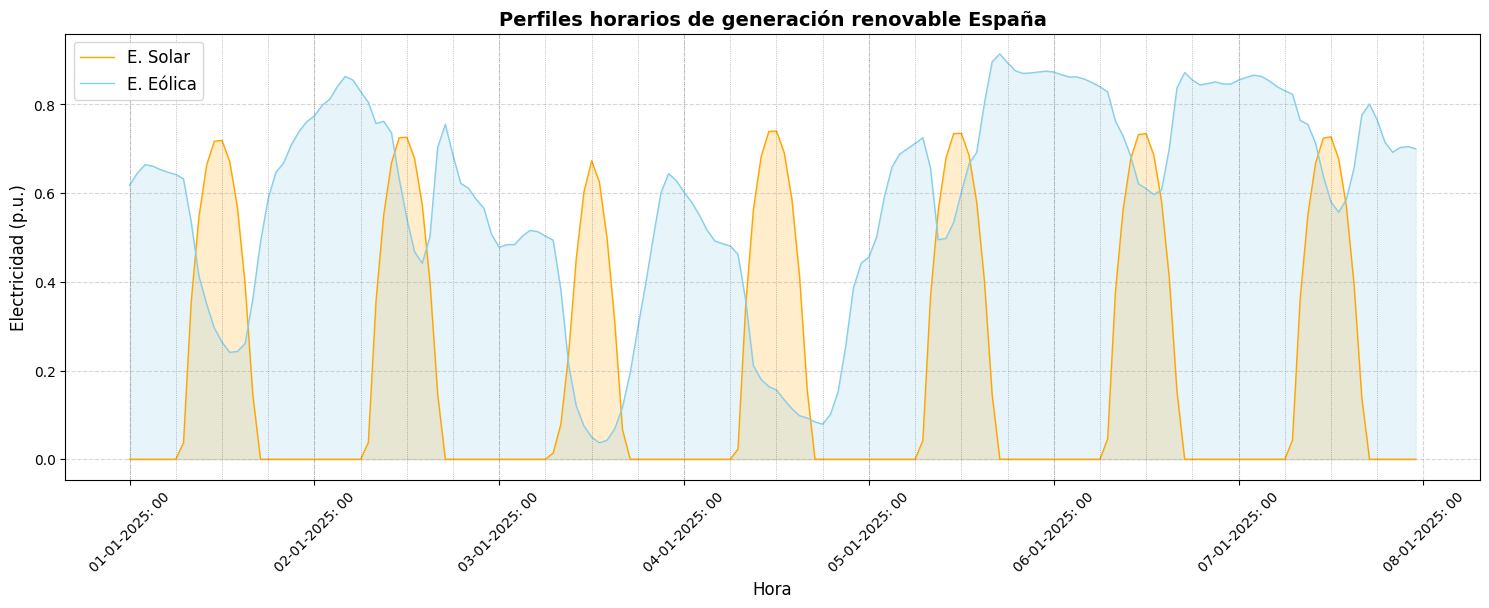

In [282]:
# GRAFICAR

# Gráfica de Perfiles Horarios de Generación Renovable.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") # para que grafique una semana completa (tengo datos para 1 año)
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, ES_solar_profile, label="E. Solar", color="orange", linewidth=1, linestyle="-")
plt.plot(hours, ES_wind_profile, label="E. Eólica", color="skyblue", linewidth=1, linestyle="-")
plt.title("Perfiles horarios de generación renovable España", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Electricidad (p.u.)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.fill_between(hours, ES_solar_profile, color="orange", alpha=0.2)
plt.fill_between(hours, ES_wind_profile, color="skyblue", alpha=0.2)

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()



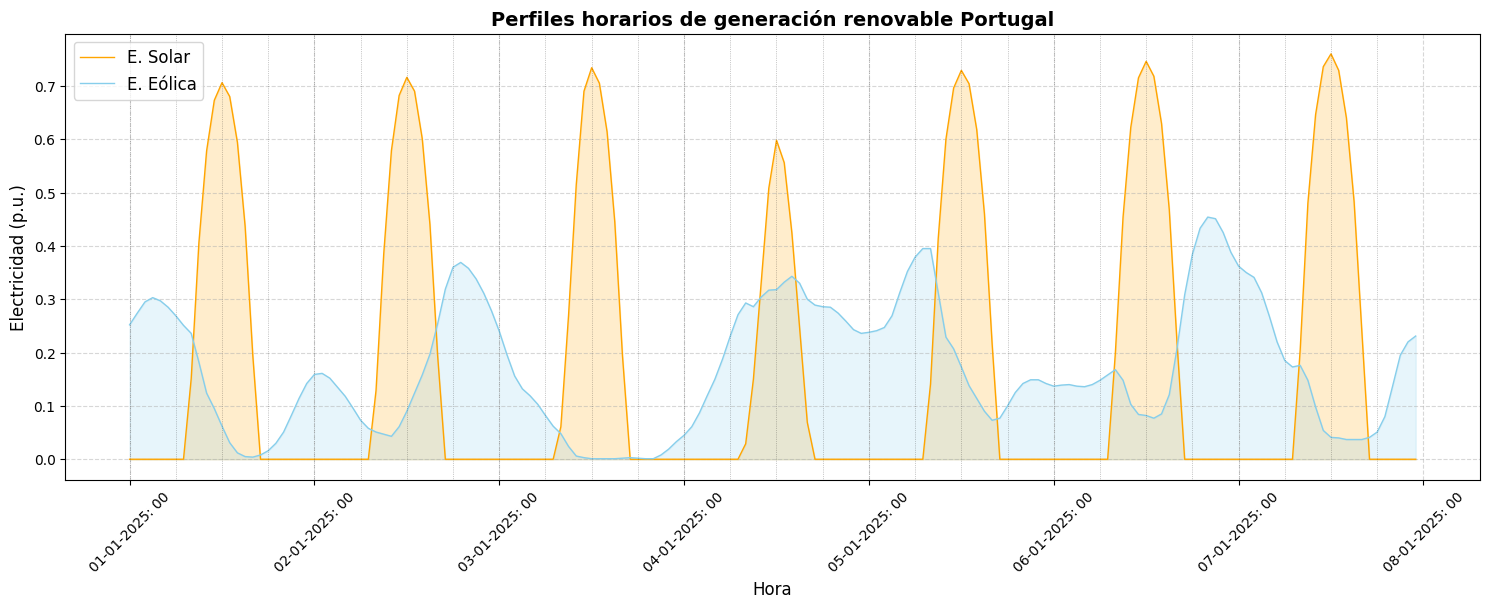

In [283]:
# GRAFICAR

# Gráfica de Perfiles Horarios de Generación Renovable.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") # para que grafique una semana completa (tengo datos para 1 año)
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, PT_solar_profile, label="E. Solar", color="orange", linewidth=1, linestyle="-")
plt.plot(hours, PT_wind_profile, label="E. Eólica", color="skyblue", linewidth=1, linestyle="-")
plt.title("Perfiles horarios de generación renovable Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Electricidad (p.u.)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.fill_between(hours, PT_solar_profile, color="orange", alpha=0.2)
plt.fill_between(hours, PT_wind_profile, color="skyblue", alpha=0.2)

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

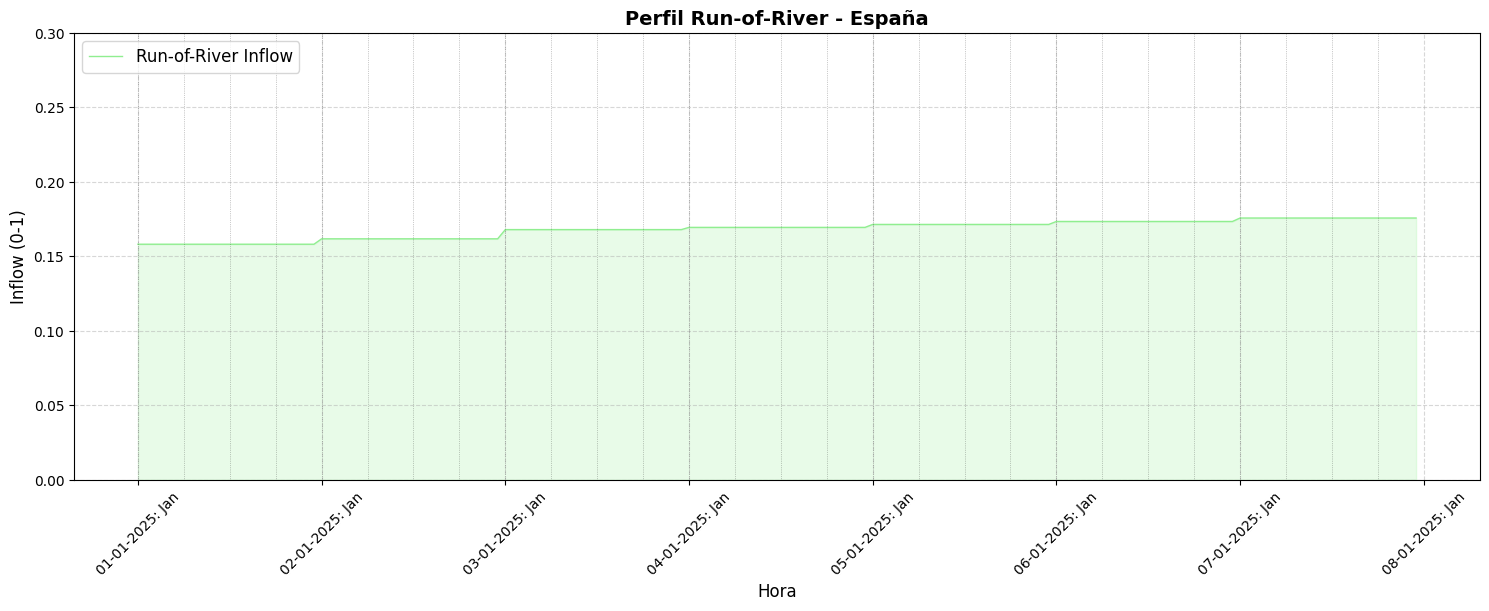

In [284]:

#Gráfica Inflow Run-of-River
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora

plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, ES_hydraulic_profile, label="Run-of-River Inflow", color="lightgreen", linewidth=1, linestyle="-")
plt.fill_between(hours, ES_hydraulic_profile, color="lightgreen", alpha=0.2)
plt.title("Perfil Run-of-River - España", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Inflow (0-1)", fontsize=12)
plt.ylim(0, 0.3)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %h'))
plt.xticks(rotation=45)
plt.show()

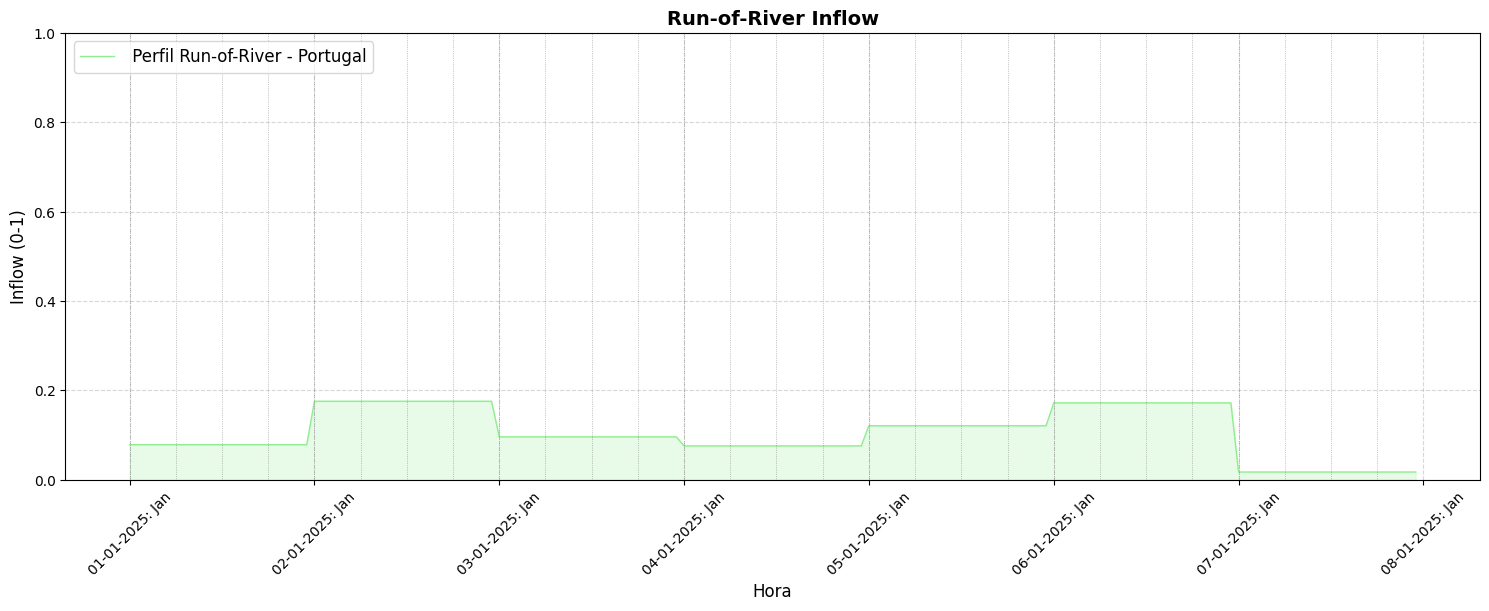

In [285]:
#Gráfica Inflow Run-of-River
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora

plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, PT_hydraulic_profile, label=" Perfil Run-of-River - Portugal", color="lightgreen", linewidth=1, linestyle="-")
plt.fill_between(hours, PT_hydraulic_profile, color="lightgreen", alpha=0.2)
plt.title("Run-of-River Inflow", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Inflow (0-1)", fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %h'))
plt.xticks(rotation=45)
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\3888001633.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



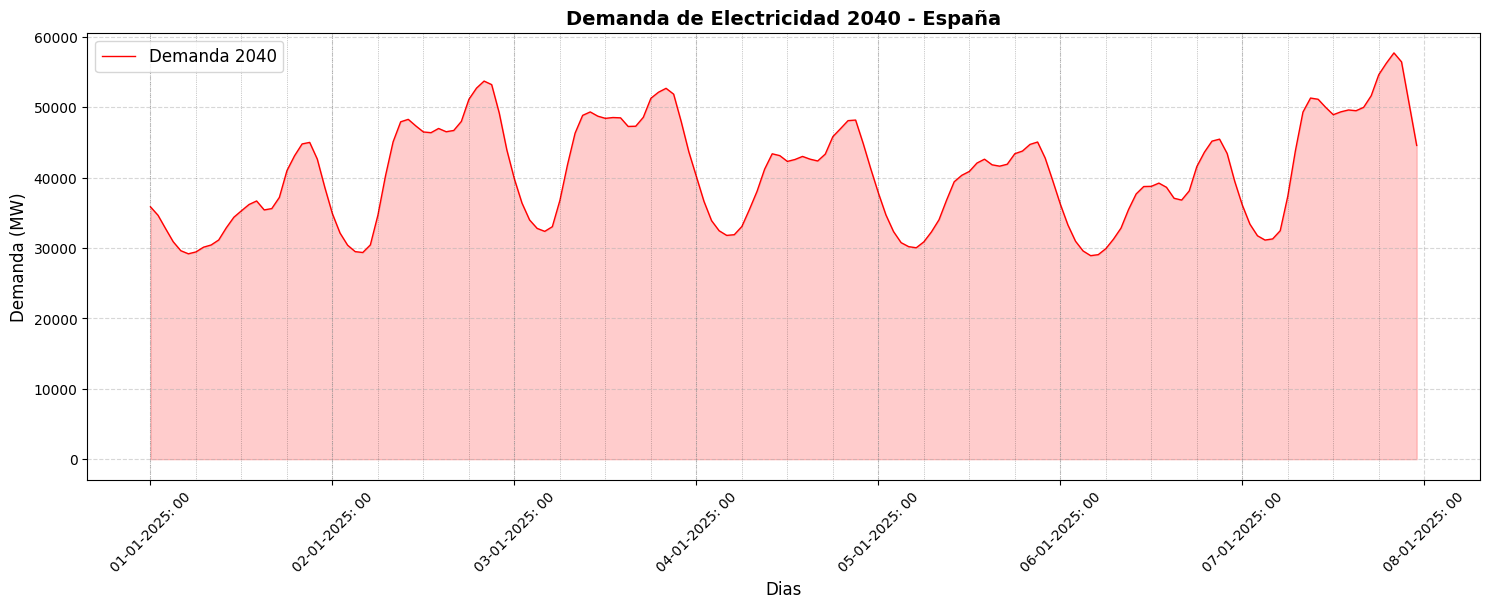

In [286]:
# Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="H") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, ES_demand_2040, label="Demanda 2040", color="red", linewidth=1, linestyle="-")
plt.fill_between(hours, ES_demand_2040, color="red", alpha=0.2)
plt.title("Demanda de Electricidad 2040 - España",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

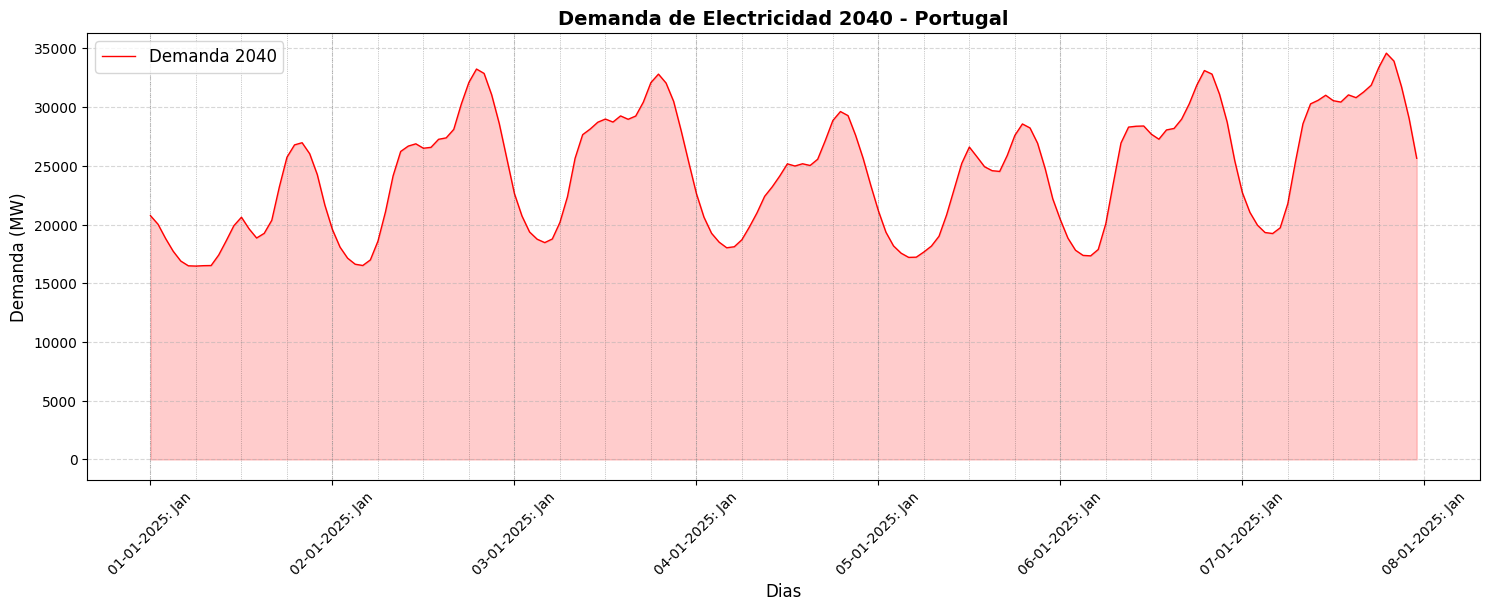

In [287]:
# Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, PT_demand_2040, label="Demanda 2040", color="red", linewidth=1, linestyle="-")
plt.fill_between(hours, PT_demand_2040, color="red", alpha=0.2)
plt.title("Demanda de Electricidad 2040 - Portugal",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %h'))
plt.xticks(rotation=45)
plt.show()

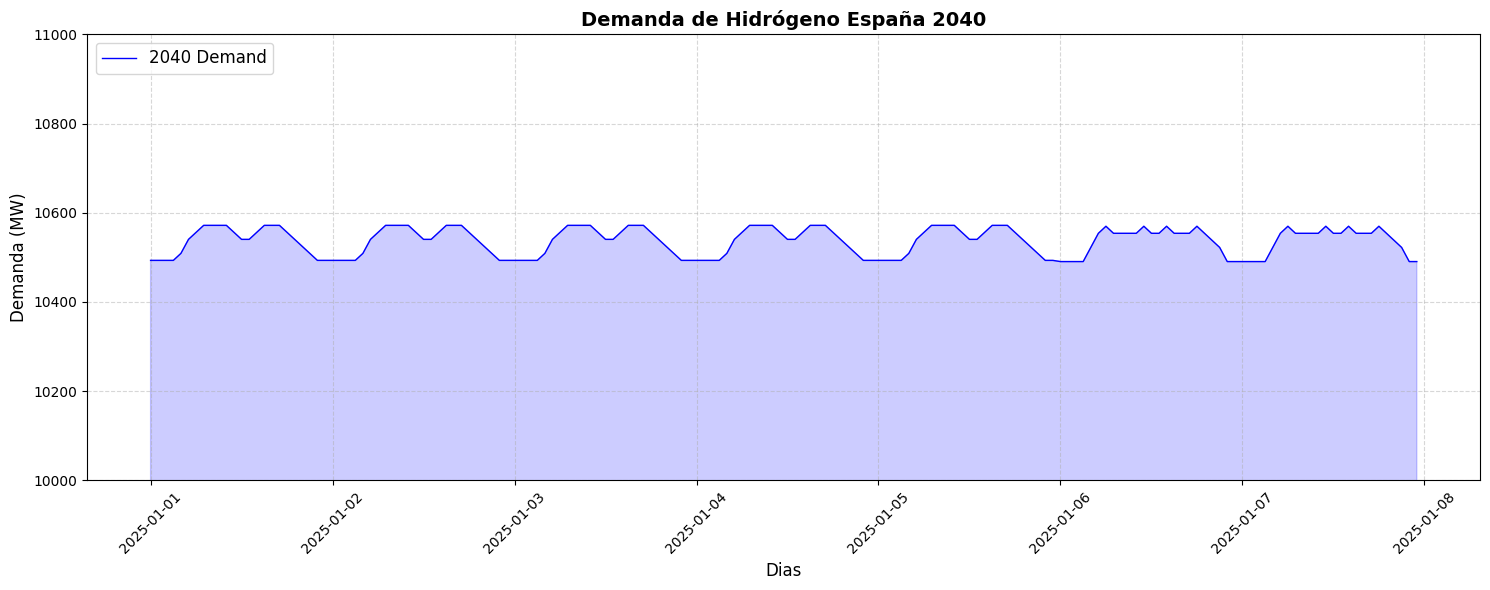

In [288]:
 # Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, ES_hydrogen_demand, label="2040 Demand", color="blue", linewidth=1, linestyle="-")
plt.fill_between(hours, ES_hydrogen_demand, color="blue", alpha=0.2)
plt.title("Demanda de Hidrógeno España 2040",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.ylim(10000, 11000)


plt.xticks(rotation=45)
plt.show()

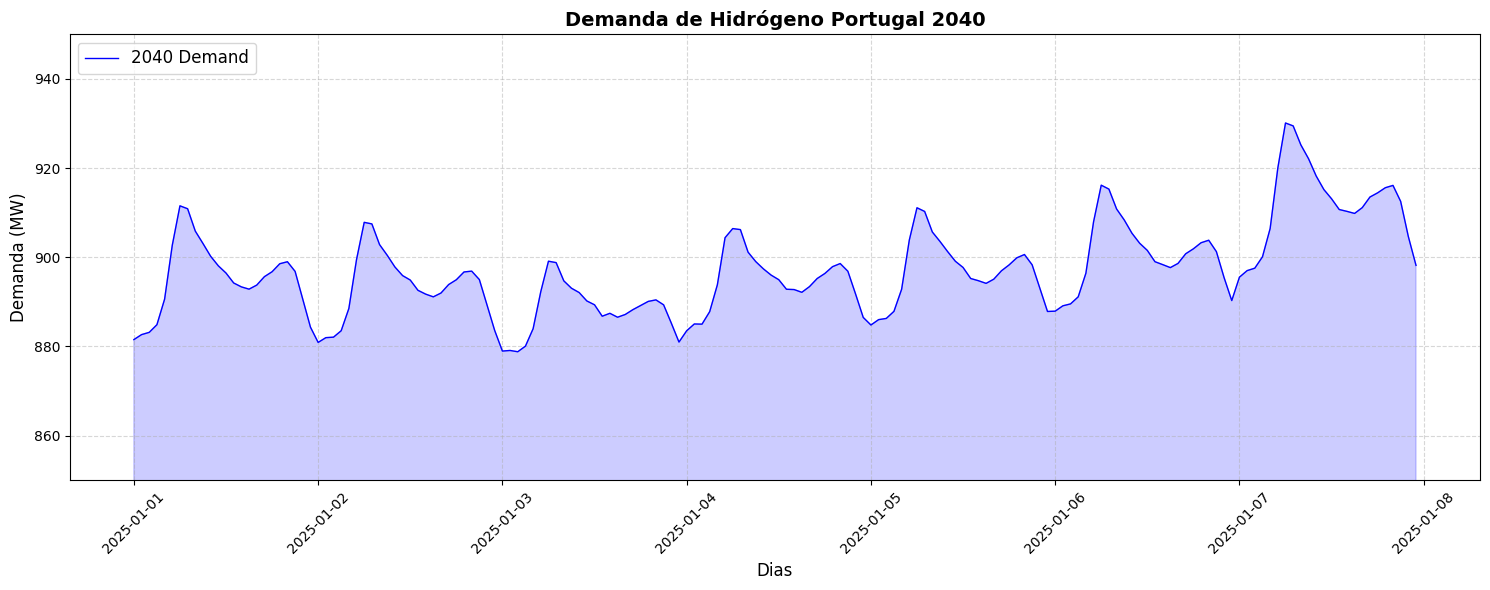

In [289]:
 # Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, PT_hydrogen_demand, label="2040 Demand", color="blue", linewidth=1, linestyle="-")
plt.fill_between(hours, PT_hydrogen_demand, color="blue", alpha=0.2)
plt.title("Demanda de Hidrógeno Portugal 2040",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.ylim(850, 950)

plt.xticks(rotation=45)
plt.show()

PARTE II: CREACIÓN DEL ENTORNO: Llamada a Componentes

In [290]:
# CARRIERS
df_carriers = data["carriers"]

for _, carrier in df_carriers.iterrows():
    network.add(
        "Carrier",
        carrier["name"].strip(),
        overwrite=carrier["overwrite"]
    )

# Verificación con API moderna
print("\n=== Carriers añadidos ===")
print(network.carriers.static)




=== Carriers añadidos ===
             co2_emissions color nice_name  max_growth  max_relative_growth
name                                                                       
AC                     0.0                         inf                  0.0
water                  0.0                         inf                  0.0
wind                   0.0                         inf                  0.0
gas                    0.0                         inf                  0.0
solar                  0.0                         inf                  0.0
grid_import            0.0                         inf                  0.0
biomass                0.0                         inf                  0.0
hydrogen               0.0                         inf                  0.0


In [291]:
# BUSES
df_buses = data["buses"]

for _, bus in df_buses.iterrows():
    network.add(
        "Bus",
        bus["name"].strip(),
        carrier=bus["carrier"].strip(),
        overwrite=bus["overwrite"]
    )

# Verificación con API moderna
print("\n=== Buses añadidos ===")
print(network.buses.static)  



=== Buses añadidos ===
                           v_nom type    x    y   carrier unit location  \
name                                                                      
ES_electricity_market_bus    1.0       0.0  0.0        AC                 
ES_water_bus                 1.0       0.0  0.0     water                 
ES_gas_bus                   1.0       0.0  0.0       gas                 
ES_hydrogen_bus              1.0       0.0  0.0  hydrogen                 
PT_electricity_market_bus    1.0       0.0  0.0        AC                 
PT_water_bus                 1.0       0.0  0.0     water                 
PT_gas_bus                   1.0       0.0  0.0       gas                 
PT_hydrogen_bus              1.0       0.0  0.0  hydrogen                 

                           v_mag_pu_set  v_mag_pu_min  v_mag_pu_max control  \
name                                                                          
ES_electricity_market_bus           1.0           0.0           inf

In [292]:
# GENERADORES

df_generators = data["generators"]

for _, gen in df_generators.iterrows(): 
    gen_name = gen["name"].strip() 
    carrier_key = gen["carrier"].strip().lower() 
    
    # Detectar si es ES o PT según el bus
    country = gen["bus"][:2]   # ES / PT

    # Crear el generador estático
    network.add( 
        "Generator",
        gen_name,
        bus=gen["bus"],
        p_nom=gen["p_nom"],
        # p_nom_extendable=gen["p_nom_extendable"],
        # p_nom_max=gen["p_nom_max"],
        marginal_cost=gen["marginal_cost"],
        carrier=gen["carrier"],
        overwrite=gen["overwrite"]
    )

    # Seleccionar perfil correcto según país + carrier
    if carrier_key == "solar":
        profile = ES_solar_profile if country == "ES" else PT_solar_profile
        network.generators.dynamic["p_max_pu"][gen_name] = profile.values
    elif carrier_key == "wind":
        profile = ES_wind_profile if country == "ES" else PT_wind_profile
        network.generators.dynamic["p_max_pu"][gen_name] = profile.values
    elif carrier_key == "water":
        profile = ES_hydraulic_profile if country == "ES" else PT_hydraulic_profile
        network.generators.dynamic["p_max_pu"][gen_name] = profile.values
    else:
        continue  # carrier no renovable → no tiene perfil dinámico



In [293]:
print(network.generators)
print(network.generators.dynamic["p_max_pu"].columns)

'Generator' Components
Index(['ES_solar', 'ES_wind', 'ES_water', 'PT_solar', 'PT_wind', 'PT_water'], dtype='object', name='name')


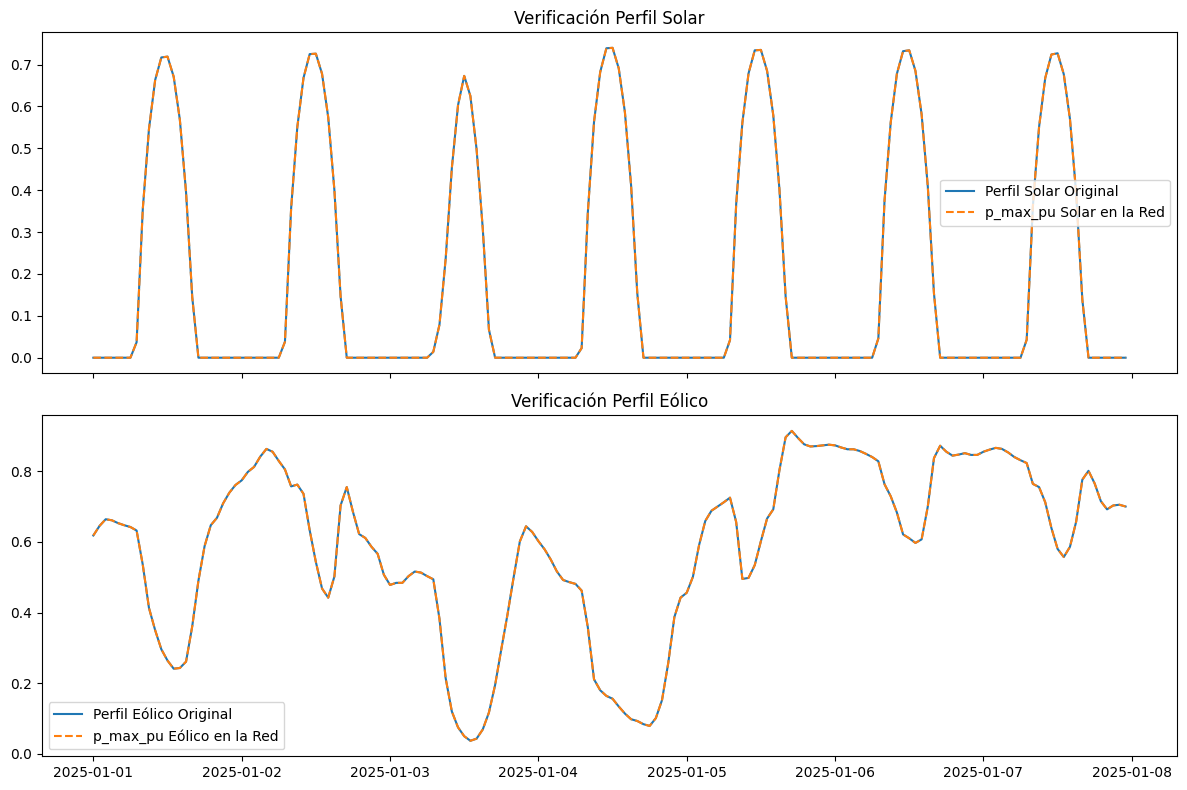

In [294]:
# Verificación de perfiles asignados correctamente: ES
ES_solar_profile.index = network.snapshots[:len(ES_solar_profile)]
ES_wind_profile.index = network.snapshots[:len(ES_wind_profile)]

# Extraer perfiles desde la red
solar_pm = network.generators.dynamic["p_max_pu"]["ES_solar"]
wind_pm  = network.generators.dynamic["p_max_pu"]["ES_wind"]

# Gráfico
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(network.snapshots[:len(solar_pm)], ES_solar_profile, label="Perfil Solar Original")
axes[0].plot(network.snapshots[:len(solar_pm)], solar_pm, linestyle="--", label="p_max_pu Solar en la Red")
axes[0].set_title("Verificación Perfil Solar")
axes[0].legend()

axes[1].plot(network.snapshots[:len(wind_pm)], ES_wind_profile, label="Perfil Eólico Original")
axes[1].plot(network.snapshots[:len(wind_pm)], wind_pm, linestyle="--", label="p_max_pu Eólico en la Red")
axes[1].set_title("Verificación Perfil Eólico")
axes[1].legend()

plt.tight_layout()
plt.show()



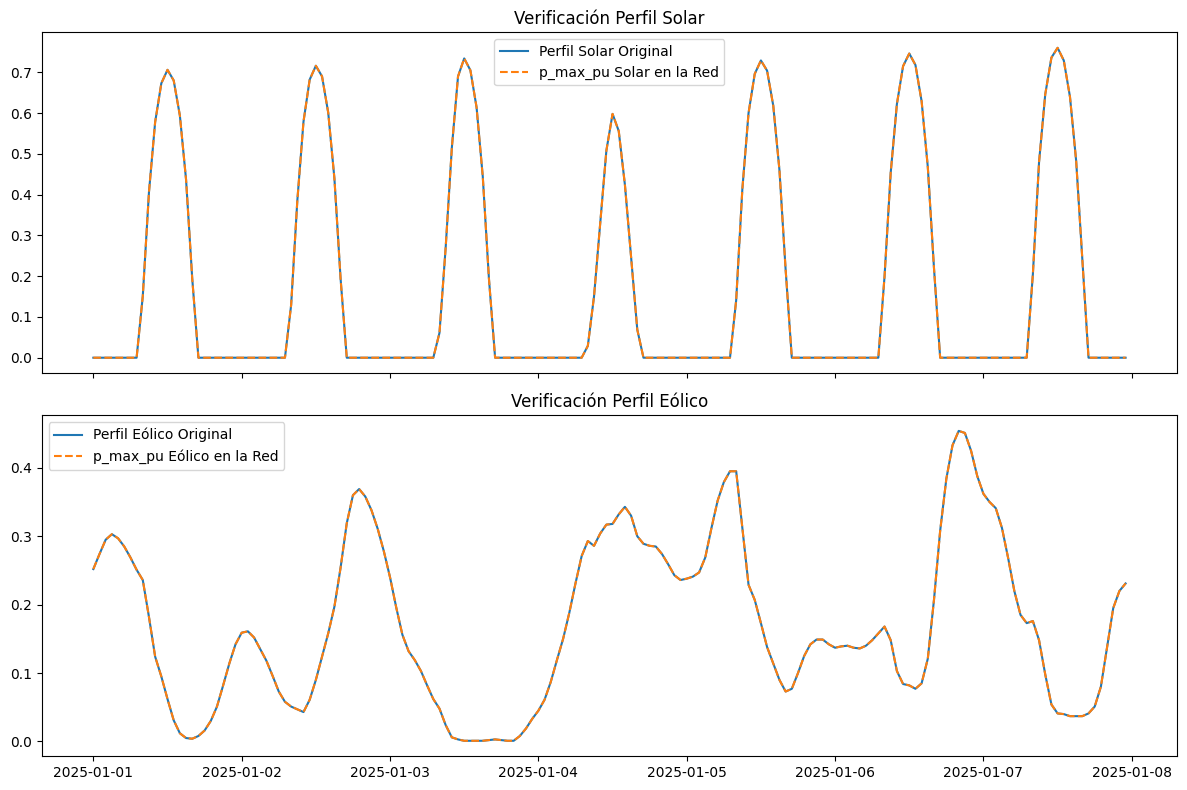

In [295]:
# Verificación de perfiles asignados correctamente: PT
PT_solar_profile.index = network.snapshots[:len(PT_solar_profile)]
PT_wind_profile.index = network.snapshots[:len(PT_wind_profile)]

# Extraer perfiles desde la red
solar_pm = network.generators.dynamic["p_max_pu"]["PT_solar"]
wind_pm  = network.generators.dynamic["p_max_pu"]["PT_wind"]

# Gráfico
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(network.snapshots[:len(solar_pm)], PT_solar_profile, label="Perfil Solar Original")
axes[0].plot(network.snapshots[:len(solar_pm)], solar_pm, linestyle="--", label="p_max_pu Solar en la Red")
axes[0].set_title("Verificación Perfil Solar")
axes[0].legend()

axes[1].plot(network.snapshots[:len(wind_pm)], PT_wind_profile, label="Perfil Eólico Original")
axes[1].plot(network.snapshots[:len(wind_pm)], wind_pm, linestyle="--", label="p_max_pu Eólico en la Red")
axes[1].set_title("Verificación Perfil Eólico")
axes[1].legend()

plt.tight_layout()
plt.show()


In [296]:
# LOADS

# CREAR SERIES DE DEMANDA
    #ESPAÑA
ES_demand_hydrogen_series = pd.Series(df_demand2040['ES_hydrogen_demand'].iloc[:len(network.snapshots)].values, index=network.snapshots)
ES_demand_series = pd.Series(df_demand2040['ES_demand_2040'].iloc[:len(network.snapshots)].values, index=network.snapshots)
    #PORTUGAL
PT_demand_hydrogen_series = pd.Series(df_demand2040['PT_hydrogen_demand'].iloc[:len(network.snapshots)].values, index=network.snapshots)
PT_demand_series = pd.Series(df_demand2040['PT_demand_2040'].iloc[:len(network.snapshots)].values, index=network.snapshots)

# Añadir variables estáticas
df_loads = data["loads"]
for _, load in df_loads.iterrows():
    network.add(
        "Load",
        load["name"].strip(),
        bus=load["bus"].strip(),
        carrier=load["carrier"].strip(),
        overwrite=load["overwrite"]
    )

# Asignar variables dinámicas
    #ESPAÑA
network.loads.dynamic["p_set"]["ES_hydrogen_demand"] = ES_demand_hydrogen_series.values
network.loads.dynamic["p_set"]["ES_demand_2040"] = ES_demand_series.values
    #PORTUGAL
network.loads.dynamic["p_set"]["PT_hydrogen_demand"] = PT_demand_hydrogen_series.values
network.loads.dynamic["p_set"]["PT_demand_2040"] = PT_demand_series.values

# Verificación con API moderna
print("\n=== Loads estáticos ===")
print(network.loads.static)

print("\n=== Primeras filas de p_set dinámico ===")
print(network.loads.dynamic["p_set"].head())



=== Loads estáticos ===
                                          bus   carrier type  p_set  q_set  \
name                                                                         
ES_demand_2040      ES_electricity_market_bus        AC         0.0    0.0   
ES_hydrogen_demand            ES_hydrogen_bus  hydrogen         0.0    0.0   
PT_demand_2040      PT_electricity_market_bus        AC         0.0    0.0   
PT_hydrogen_demand            PT_hydrogen_bus  hydrogen         0.0    0.0   

                    sign  active  
name                              
ES_demand_2040      -1.0    True  
ES_hydrogen_demand  -1.0    True  
PT_demand_2040      -1.0    True  
PT_hydrogen_demand  -1.0    True  

=== Primeras filas de p_set dinámico ===
name                 ES_hydrogen_demand  ES_demand_2040  PT_hydrogen_demand  \
snapshot                                                                      
2025-01-01 00:00:00         10493.06584    35845.954713          881.545028   
2025-01-01 01:00:

In [297]:
df_links = data["links"]

for _, lk in df_links.iterrows():

    name = lk["name"].strip().lower()
    link_name = lk["name"].strip()

    # Detectar país desde bus0
    country = lk["bus0"][:2]   # ES / PT

    # Añadir link estático
    network.add(
        "Link",
        link_name,
        bus0=lk["bus0"].strip(),
        bus1=lk["bus1"].strip(),
        p_nom=lk["p_nom"],
        efficiency=lk["efficiency"],
        marginal_cost=lk["marginal_cost"],
        carrier=lk["carrier"],
        capital_cost=lk["capital_cost"],
        overwrite=lk["overwrite"]
    )



In [298]:
# Verificación
     
print("\n=== Resumen de todos los Links en la red ===")
print(network.links.static[['bus0','bus1','p_nom','efficiency','marginal_cost','carrier']])
for link_name in ["CCGT", "turbina", "pump", "electrolyzer"]:
        if link_name in network.links.static.index:
            row = network.links.static.loc[link_name]
            print(f"\n--- Detalle de {link_name} ---")
            print(f"Origen (bus0):        {row['bus0']}")
            print(f"Destino (bus1):       {row['bus1']}")
            print(f"Capacidad (p_nom):    {row['p_nom']} MW")
            print(f"Eficiencia:           {row['efficiency']*100:.1f}%")
            print(f"Coste marginal:       {row['marginal_cost']} €/MWh")
            print(f"Carrier:              {row['carrier']}")
            # Ramp limits solo para CCGT
            #if link_name == "CCGT":
            #    print(f"Ramp up limit:        {row['ramp_limit_up']} MW/h")
            #    print(f"Ramp down limit:      {row['ramp_limit_down']} MW/h")
        else:
            print(f"\n⚠️ El link '{link_name}' no se encontró en la red.")


=== Resumen de todos los Links en la red ===
                                                       bus0  \
name                                                          
ES_CCGT                                          ES_gas_bus   
ES_turbina                                     ES_water_bus   
ES_pump                           ES_electricity_market_bus   
ES_electrolyzer                   ES_electricity_market_bus   
PT_CCGT                                          PT_gas_bus   
PT_turbina                                     PT_water_bus   
PT_pump                           PT_electricity_market_bus   
PT_electrolyzer                   PT_electricity_market_bus   
ES_PT_interconexion_electricidad  ES_electricity_market_bus   
ES_PT_interconexion_hidrogeno               ES_hydrogen_bus   
PT_ES_interconexion_electricidad  PT_electricity_market_bus   
PT_ES_interconexion_hidrogeno               PT_hydrogen_bus   

                                                       bus1          p_

In [299]:
print("\nLINKS ESTÁTICOS:")
print(network.links.static.index)

print("\nCOLUMNAS EN p_max_pu:")
print(network.links.dynamic["p_max_pu"].columns)

print("\nCOLUMNAS EN p0:")
print(network.links_t.p0.columns)


LINKS ESTÁTICOS:
Index(['ES_CCGT', 'ES_turbina', 'ES_pump', 'ES_electrolyzer', 'PT_CCGT',
       'PT_turbina', 'PT_pump', 'PT_electrolyzer',
       'ES_PT_interconexion_electricidad', 'ES_PT_interconexion_hidrogeno',
       'PT_ES_interconexion_electricidad', 'PT_ES_interconexion_hidrogeno'],
      dtype='object', name='name')

COLUMNAS EN p_max_pu:
Index([], dtype='object', name='name')

COLUMNAS EN p0:
Index([], dtype='object', name='name')


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\4154381567.py:8: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



In [300]:

df_storage = data["storage_units"]

for _, st in df_storage.iterrows():
    name = st["name"].strip()

    # Añadir atributos estáticos
    network.add(
        "StorageUnit",
        name,
        bus=st["bus"].strip(),
        p_nom=st["p_nom"],
        max_hours=st["max_hours"],
        efficiency_store=st["efficiency_store"],
        efficiency_dispatch=st["efficiency_dispatch"],
        marginal_cost=st["marginal_cost"],
        carrier=st["carrier"],
        overwrite=st["overwrite"],
        capital_cost=st.get("capital_cost", 0),  # si existe
        #state_of_charge_initial=0.5 * st["p_nom"] * st["max_hours"],  
        cyclic_state_of_charge=False
    )

    print(f"✅ StorageUnit '{name}' añadida en bus {st['bus']}: {st['p_nom']} MW · {st['max_hours']} h")

# Verificación
print("\n=== Storage Units estáticos ===")
print(network.storage_units.static.head())

print("\n=== Storage Units dinámicos ===")
print(network.storage_units.dynamic.keys())


✅ StorageUnit 'ES_electricity_market_battery' añadida en bus ES_electricity_market_bus: 26698.52 MW · 4 h
✅ StorageUnit 'ES_hydrogen_storage' añadida en bus ES_hydrogen_bus: 10000.0 MW · 1000 h
✅ StorageUnit 'PT_electricity_market_battery' añadida en bus PT_electricity_market_bus: 3000.0 MW · 4 h
✅ StorageUnit 'PT_hydrogen_storage' añadida en bus PT_hydrogen_bus: 10000.0 MW · 1000 h

=== Storage Units estáticos ===
                                                     bus control type  \
name                                                                    
ES_electricity_market_battery  ES_electricity_market_bus      PQ        
ES_hydrogen_storage                      ES_hydrogen_bus      PQ        
PT_electricity_market_battery  PT_electricity_market_bus      PQ        
PT_hydrogen_storage                      PT_hydrogen_bus      PQ        

                                  p_nom  p_nom_mod  p_nom_extendable  \
name                                                                  

In [301]:
df_store = data["store"].copy()
 
# normaliza la columna a boolean REAL
df_store["cyclic_state_of_charge"] = (
    df_store["cyclic_state_of_charge"]
    .astype(str).str.strip().str.lower()
    .map({"true": True, "false": False, "1": True, "0": False, "nan": False})
)
 
# si algo no mapea, lo dejamos en False (o lanza error si prefieres)
df_store["cyclic_state_of_charge"] = df_store["cyclic_state_of_charge"].fillna(False)

In [302]:


for _, store in df_store.iterrows():
    network.add(
        "Store",
        store["name"].strip(),
        bus=store["bus"].strip(),
        e_nom=store["e_nom"],
        e_initial=store["e_initial"], 
        e_min_pu=store["e_min_pu"],
        e_max_pu=store["e_max_pu"],
        e_cyclic=store["cyclic_state_of_charge"],
        capital_cost=store["capital_cost"],
        marginal_cost=store["marginal_cost"],
        carrier=store["carrier"],
        overwrite=store["overwrite"]
    )

    print(f"✅ Store '{store['name']}' añadida en bus {store['bus']}: "
          f"{store['e_nom']} MWh · inicial {store['e_initial']} MWh · "
          f"min {store['e_min_pu']} pu · max {store['e_max_pu']} pu · "
          f"coste marginal {store['marginal_cost']}")

# Verificación con API moderna
print("\n=== Stores estáticos ===")
print(network.stores.static.head())


✅ Store 'ES_embalse' añadida en bus ES_water_bus: 1387684000 MWh · inicial 1248915600 MWh · min 0.2 pu · max 0.9 pu · coste marginal 1
✅ Store 'PT_embalse' añadida en bus PT_water_bus: 3307600 MWh · inicial 2976840 MWh · min 0.2 pu · max 0.9 pu · coste marginal 1

=== Stores estáticos ===
                     bus type carrier         e_nom  e_nom_mod  \
name                                                             
ES_embalse  ES_water_bus        water  1.387684e+09        0.0   
PT_embalse  PT_water_bus        water  3.307600e+06        0.0   

            e_nom_extendable  e_nom_min  e_nom_max  e_nom_set  e_min_pu  ...  \
name                                                                     ...   
ES_embalse             False        0.0        inf        NaN       0.2  ...   
PT_embalse             False        0.0        inf        NaN       0.2  ...   

            sign  marginal_cost  marginal_cost_quadratic  \
name                                                       
ES_e

RESTRICCIONES

In [303]:
# Precio de CO2 y factor de emisión
co2_price = 100  # €/tCO2
emission_factor = 0.202  # tCO2/MWh

# Coste adicional por CO2
co2_cost = co2_price * emission_factor  # 20.2 €/MWh

# Acceso correcto en tu versión de PyPSA
network.links.df.loc["ES_CCGT", "marginal_cost"] += co2_cost
network.links.df.loc["PT_CCGT", "marginal_cost"] += co2_cost

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\2149582192.py:9: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\2149582192.py:10: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.



PARTE III: OPTIMIZACIÓN

In [304]:
network.optimize(solver_name="highs")

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.15s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 6384 primals, 14448 duals
Objective: 6.81e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

PARTE IV: OBTENCIÓN DE RESULTADOS.

{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x1beb90d9490>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x1beb91f81d0>},
 'flows': {}}

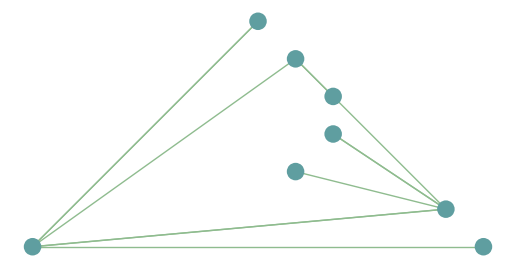

In [305]:
network.plot(bus_sizes=0.001, link_widths=1)

In [306]:
# RESULTADOS NUMÉRICOS QUE CUBREN LA DEMANDA
print(" Generator p:", network.generators_t.p.iloc[0])
print("Link p0:",     network.links_t.p0.iloc[0])
print("Link p1:",     network.links_t.p1.iloc[0])
print(" Load p:",      network.loads_t.p_set.iloc[0])

 Generator p: name
ES_solar         -0.000000
ES_wind       61898.479244
ES_biomass       -0.000000
ES_gas           -0.000000
ES_water         -0.000000
PT_solar         -0.000000
PT_wind       11194.646400
PT_biomass       -0.000000
PT_gas           -0.000000
PT_water         39.876589
Name: 2025-01-01 00:00:00, dtype: float64
Link p0: name
ES_CCGT                                -0.000000
ES_turbina                             -0.000000
ES_pump                                -0.000000
ES_electrolyzer                     16281.735124
PT_CCGT                                -0.000000
PT_turbina                             -0.000000
PT_pump                                -0.000000
PT_electrolyzer                        -0.000000
ES_PT_interconexion_electricidad     9770.789408
ES_PT_interconexion_hidrogeno         904.148747
PT_ES_interconexion_electricidad       -0.000000
PT_ES_interconexion_hidrogeno          -0.000000
Name: 2025-01-01 00:00:00, dtype: float64
Link p1: name
ES_CCGT    

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\543772787.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\543772787.py:3: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\543772787.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\543772787.py:5: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` a

In [307]:
# Guardar resultados en un archivo Excel
network.export_to_excel(
    r"C:\Users\EXT10348\Downloads\WinPython 3.12.10\WPy64-31241\PROYECTOS PYPSA\Dispatching-Project-in-PypSA\Modelo_España_Portugal\Resultados\ES_PT_Unidos.xlsx",
    engine="openpyxl"
)

INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\EXT10348\Downloads\WinPython 3.12.10\WPy64-31241\PROYECTOS PYPSA\Dispatching-Project-in-PypSA\Modelo_España_Portugal\Resultados\ES_PT_Unidos.xlsx contains: sub_networks, stores, generators, loads, storage_units, links, carriers, buses


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\3706631206.py:6: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\3706631206.py:7: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\3706631206.py:34: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\3706631206.py:36: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



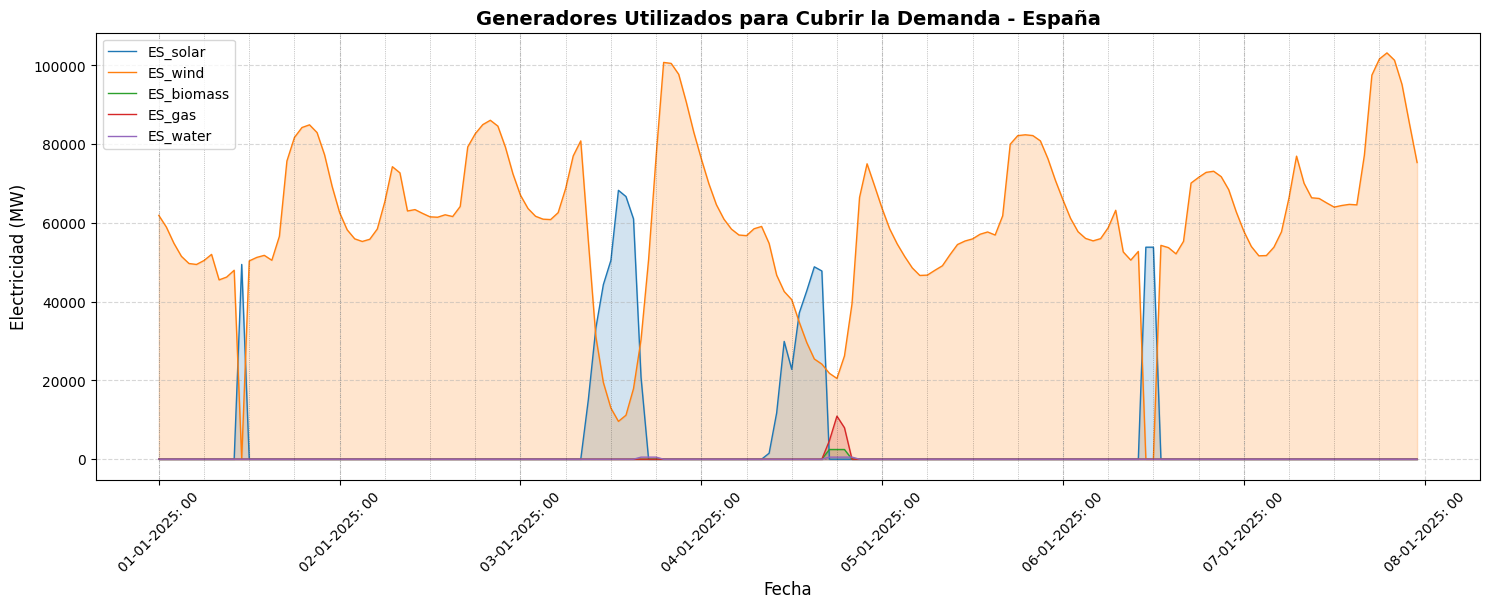

In [308]:

# GENERADORES UTILIZADOS EN ESPAÑA PARA CUBRIR DEMANDA: con este plot podemos graficar la aportación de los generadores sólo de España (sabiendo que los buses de España empiezan por "ES_")
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Para soportar los cambios de versiones de API en PyPSA 
try:
    # API nueva: componentes con .df
    gen_df = network.components["Generator"].df
    buses_df = network.components["Bus"].df
except (AttributeError, KeyError):
    # API clásica: DataFrames directos
    gen_df = network.generators
    buses_df = network.buses
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Definir qué es "España" para los buses ===
# nombre del bus (prefijo ES_)
is_es_bus = buses_df.index.str.startswith("ES_")
# Lista de buses de España
es_buses = set(buses_df.index[is_es_bus])
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Filtrar generadores cuyo 'bus' pertenece a España ===
if "bus" in gen_df.columns:
    generadores_es = gen_df.index[gen_df["bus"].isin(es_buses)]
else:
    # Fallback por nombre si faltara la columna 'bus'
    generadores_es = gen_df.index[gen_df.index.str.startswith("ES_")]
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Rango temporal ===
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h")
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Graficar potencia sólo de generadores de España ===
plt.figure(figsize=(15, 6))
plt.style.use('default')
# En PyPSA, las series temporales de generadores están en network.generators_t.p
# Aseguramos que existan y filtramos por nuestras columnas
cols_disponibles = [g for g in generadores_es if g in network.generators_t.p.columns]
for gen in cols_disponibles:
    y = network.generators_t.p[gen].reindex(hours)  # alinear al rango
    plt.plot(hours, y, label=gen, linewidth=1)
    plt.fill_between(hours, y, color=plt.gca().lines[-1].get_color(), alpha=0.2)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Personalización ===
plt.title("Generadores Utilizados para Cubrir la Demanda - España", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
# Líneas verticales cada 6 horas
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Comando de graficar
plt.show()
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\3368096690.py:6: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\3368096690.py:7: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\3368096690.py:33: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\3368096690.py:36: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



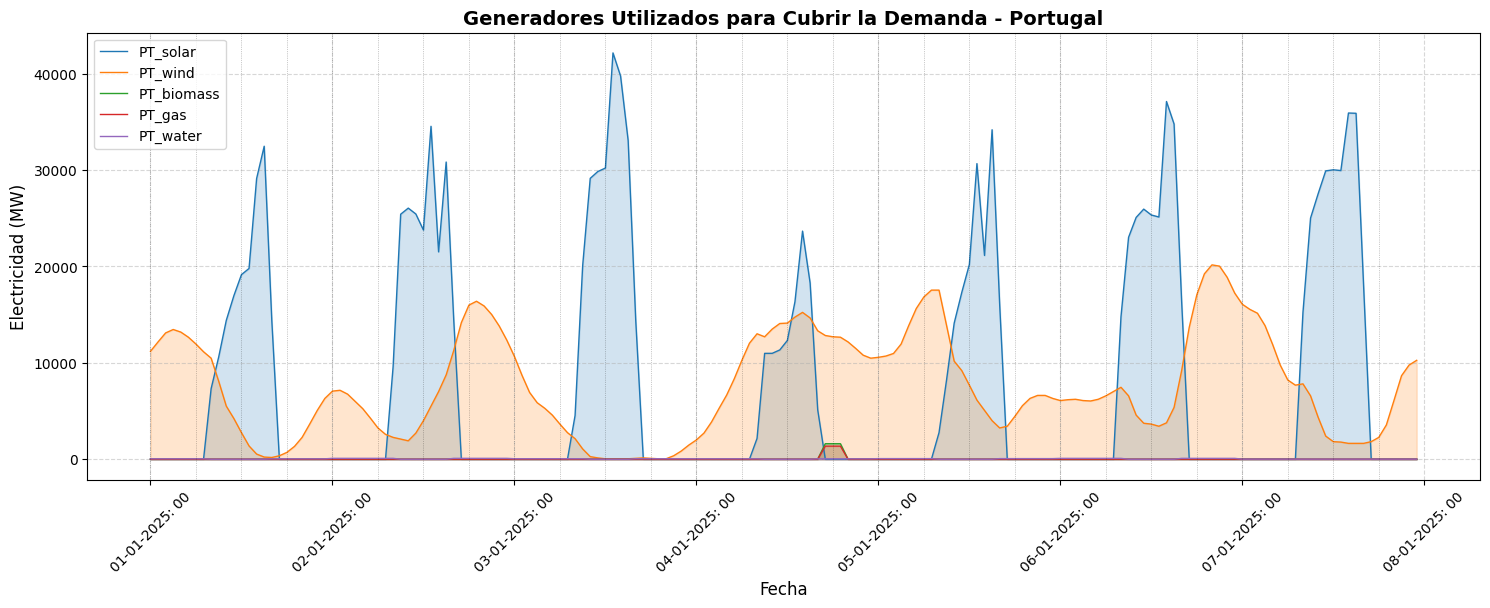

In [309]:
# GENERADORES UTILIZADOS EN PORTUGAL PARA CUBRIR DEMANDA: con este plot podemos graficar la aportación de los generadores sólo de Portugal (sabiendo que los buses de Portugal empiezan por "PT_")
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Obtener DataFrames de generadores y buses (compatibles con varias versiones) ===
try:
    # API nueva (componentes con .df)
    gen_df = network.components["Generator"].df
    buses_df = network.components["Bus"].df
except (AttributeError, KeyError):
    # API clásica (atributos DataFrame)
    gen_df = network.generators
    buses_df = network.buses
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Definir qué es "Portugal" para los buses ===
# Por nombre del bus (prefijo PT_)
is_pt_bus = buses_df.index.str.startswith("PT_")
pt_buses = set(buses_df.index[is_pt_bus])
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Filtrar generadores cuyo 'bus' pertenece a Portugal ===
if "bus" in gen_df.columns:
    generadores_pt = gen_df.index[gen_df["bus"].isin(pt_buses)]
else:
    # Fallback por nombre del generador si no existe la columna 'bus'
    generadores_pt = gen_df.index[gen_df.index.str.startswith("PT_")]
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Rango temporal ===
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h")
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Graficar potencia sólo de generadores de Portugal ===
plt.figure(figsize=(15, 6))
plt.style.use('default')

# Las series temporales están en network.generators_t.p
cols_disponibles = [g for g in generadores_pt if g in network.generators_t.p.columns]

for gen in cols_disponibles:
    y = network.generators_t.p[gen].reindex(hours)  # alinear al rango
    plt.plot(hours, y, label=gen, linewidth=1)
    plt.fill_between(hours, y, color=plt.gca().lines[-1].get_color(), alpha=0.2)
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Personalización ===
plt.title("Generadores Utilizados para Cubrir la Demanda - Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()

# Líneas verticales cada 6 horas
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)

# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.show()
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\3088494741.py:1: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



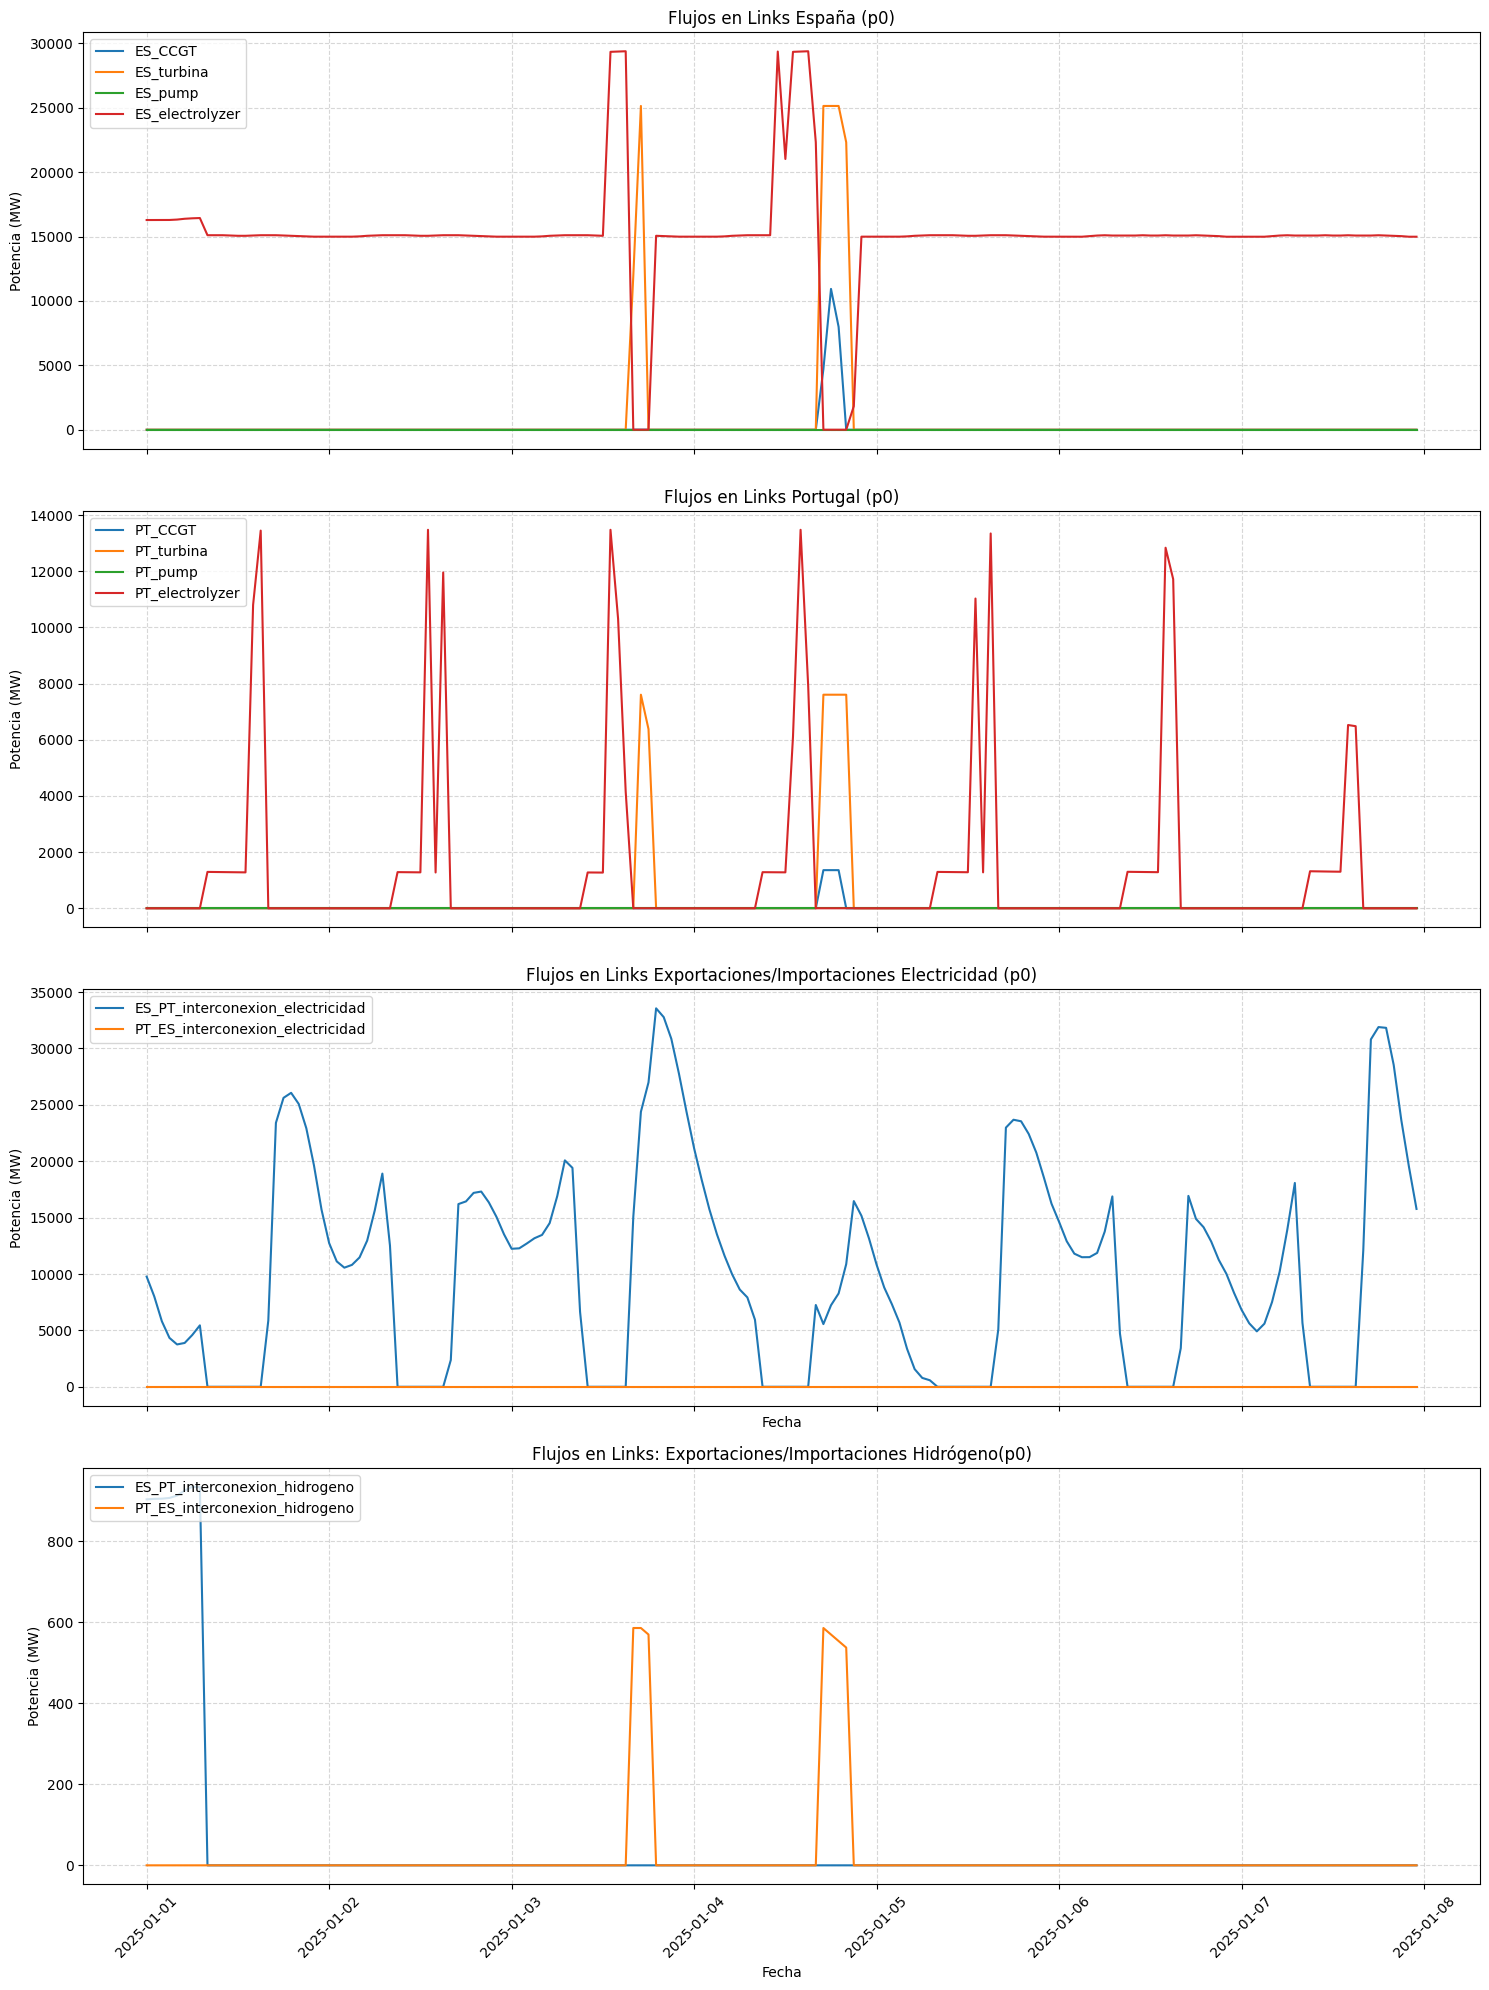

In [310]:
p0 = network.links_t.p0
links_ES = [
    "ES_CCGT",
    "ES_turbina",
    "ES_pump",
    "ES_electrolyzer",
]

links_PT = [
    "PT_CCGT",
    "PT_turbina",
    "PT_pump",
    "PT_electrolyzer",
]

links_exportaciones_electricidad = [
    "ES_PT_interconexion_electricidad",
    "PT_ES_interconexion_electricidad",
]

links_exportaciones_hidrogeno = [
    "ES_PT_interconexion_hidrogeno",
    "PT_ES_interconexion_hidrogeno",
]

# --- Crear figura con 4 subplots ---
fig, axes = plt.subplots(4, 1, figsize=(15, 20), sharex=True)  # 3 filas, 1 columna
 
# --- GRAFICO ESPAÑA ---
for link in links_ES:
    if link in p0.columns:
        axes[0].plot(network.snapshots, p0[link], label=link)
axes[0].set_title("Flujos en Links España (p0)")
axes[0].set_ylabel("Potencia (MW)")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(loc="upper left")
 
# --- GRAFICO PORTUGAL ---
for link in links_PT:
    if link in p0.columns:
        axes[1].plot(network.snapshots, p0[link], label=link)
axes[1].set_title("Flujos en Links Portugal (p0)")
axes[1].set_ylabel("Potencia (MW)")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="upper left")
 
# --- GRAFICO EXPORTACIONES electricidad ---
for link in links_exportaciones_electricidad:
    if link in p0.columns:
        axes[2].plot(network.snapshots, p0[link], label=link)
axes[2].set_title("Flujos en Links Exportaciones/Importaciones Electricidad (p0)")
axes[2].set_xlabel("Fecha")
axes[2].set_ylabel("Potencia (MW)")
axes[2].grid(True, linestyle="--", alpha=0.5)
axes[2].legend(loc="upper left")

 

# --- GRAFICO EXPORTACIONES hidrogeno---
for link in links_exportaciones_hidrogeno:
    if link in p0.columns:
        axes[3].plot(network.snapshots, p0[link], label=link)
axes[3].set_title("Flujos en Links: Exportaciones/Importaciones Hidrógeno(p0)")
axes[3].set_xlabel("Fecha")
axes[3].set_ylabel("Potencia (MW)")
axes[3].grid(True, linestyle="--", alpha=0.5)
axes[3].legend(loc="upper left")

# Ajustar diseño
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
 

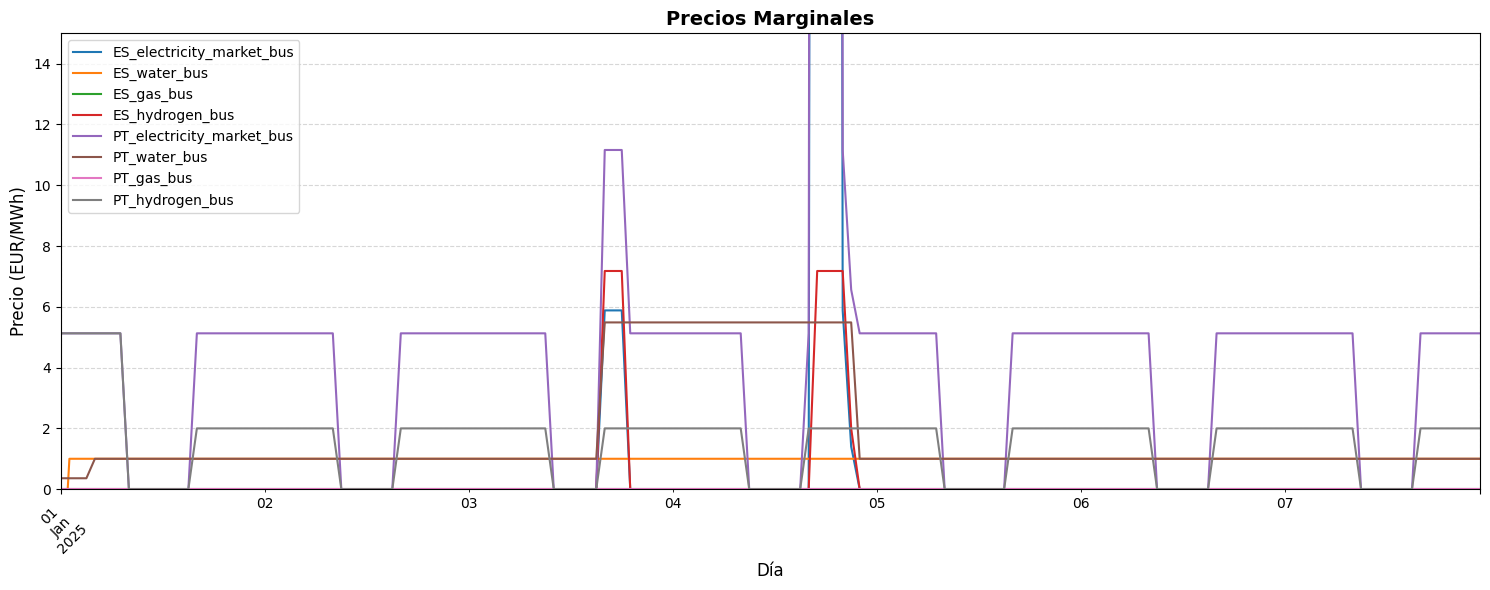

In [311]:
# PRECIOS MARGINALES con API moderna
network.buses.dynamic["marginal_price"].plot(figsize=(15, 6), title="Precios Marginales")

# Personalización
plt.title("Precios Marginales", fontsize=14, fontweight="bold")
plt.xlabel("Día", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.ylim(0, 15)
plt.tight_layout()
plt.show()

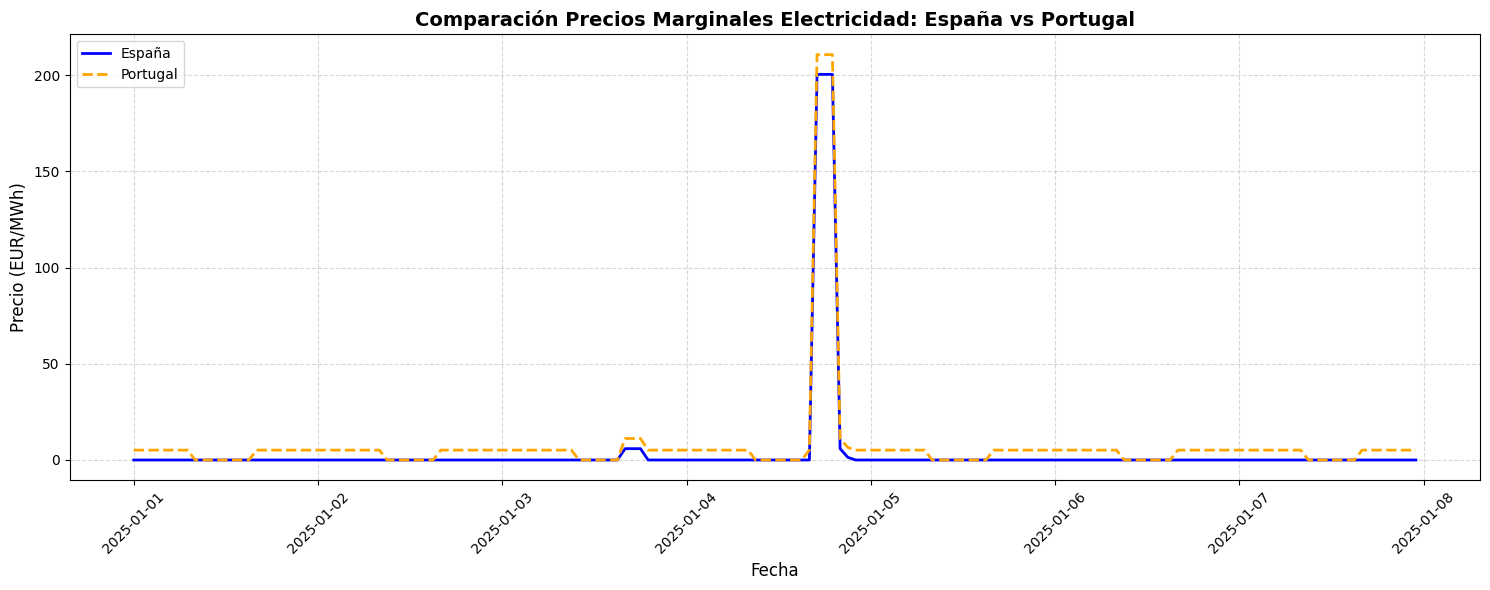

In [312]:

# Filtrar precios marginales para buses eléctricos
marginal_prices = network.buses.dynamic["marginal_price"]

# Seleccionar columnas específicas
cols_electricity = ["ES_electricity_market_bus", "PT_electricity_market_bus"]

# Verificar que existen en el DataFrame
available_cols = [col for col in cols_electricity if col in marginal_prices.columns]

# Graficar con estilos diferentes
plt.figure(figsize=(15, 6))

if "ES_electricity_market_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["ES_electricity_market_bus"],
             label="España", color="blue", linestyle="-", linewidth=2)  # Línea continua

if "PT_electricity_market_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["PT_electricity_market_bus"],
             label="Portugal", color="orange", linestyle="--", linewidth=2)  # Línea discontinua

# Personalización
plt.title("Comparación Precios Marginales Electricidad: España vs Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

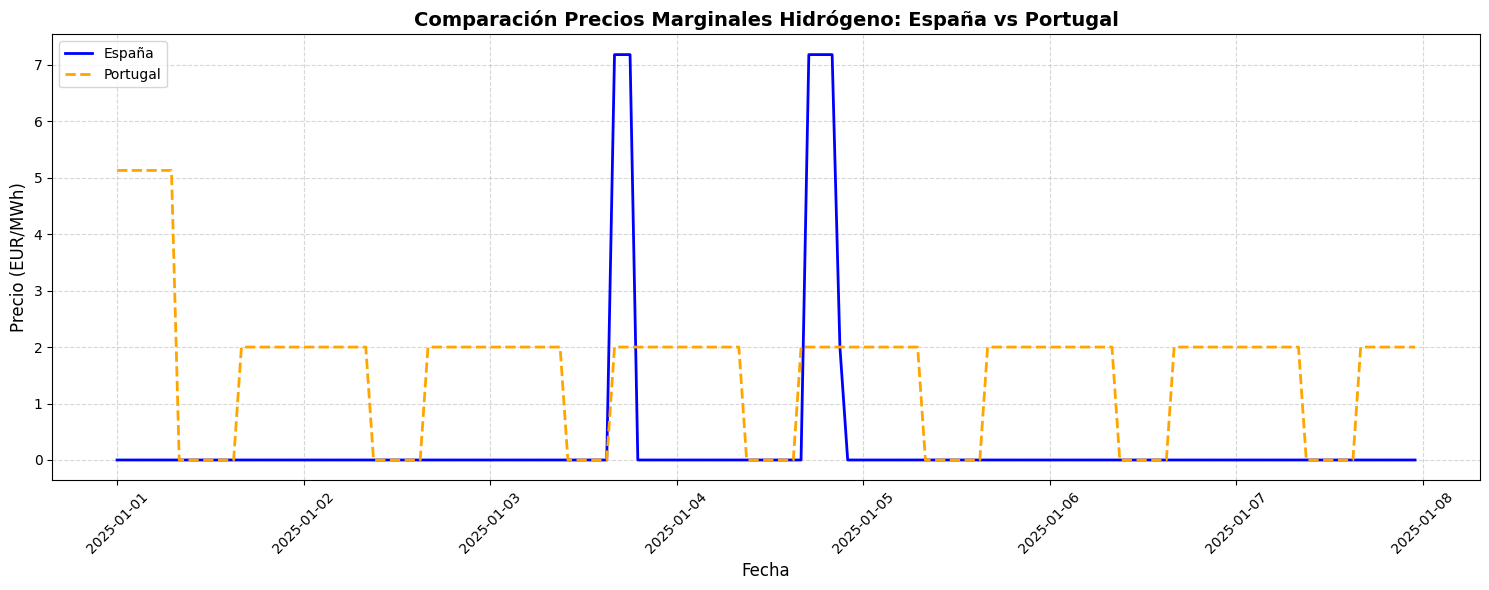

In [313]:
# Filtrar precios marginales para buses eléctricos
marginal_prices = network.buses.dynamic["marginal_price"]

# Seleccionar columnas específicas
cols_electricity = ["ES_hydrogen_bus", "PT_hydrogen_bus"]

# Verificar que existen en el DataFrame
available_cols = [col for col in cols_electricity if col in marginal_prices.columns]

# Graficar con estilos diferentes
plt.figure(figsize=(15, 6))

if "ES_hydrogen_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["ES_hydrogen_bus"],
             label="España", color="blue", linestyle="-", linewidth=2)  # Línea continua

if "PT_hydrogen_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["PT_hydrogen_bus"],
             label="Portugal", color="orange", linestyle="--", linewidth=2)  # Línea discontinua

# Personalización
plt.title("Comparación Precios Marginales Hidrógeno: España vs Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\1029378261.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\1029378261.py:29: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\1029378261.py:38: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\1029378261.py:41: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dyn

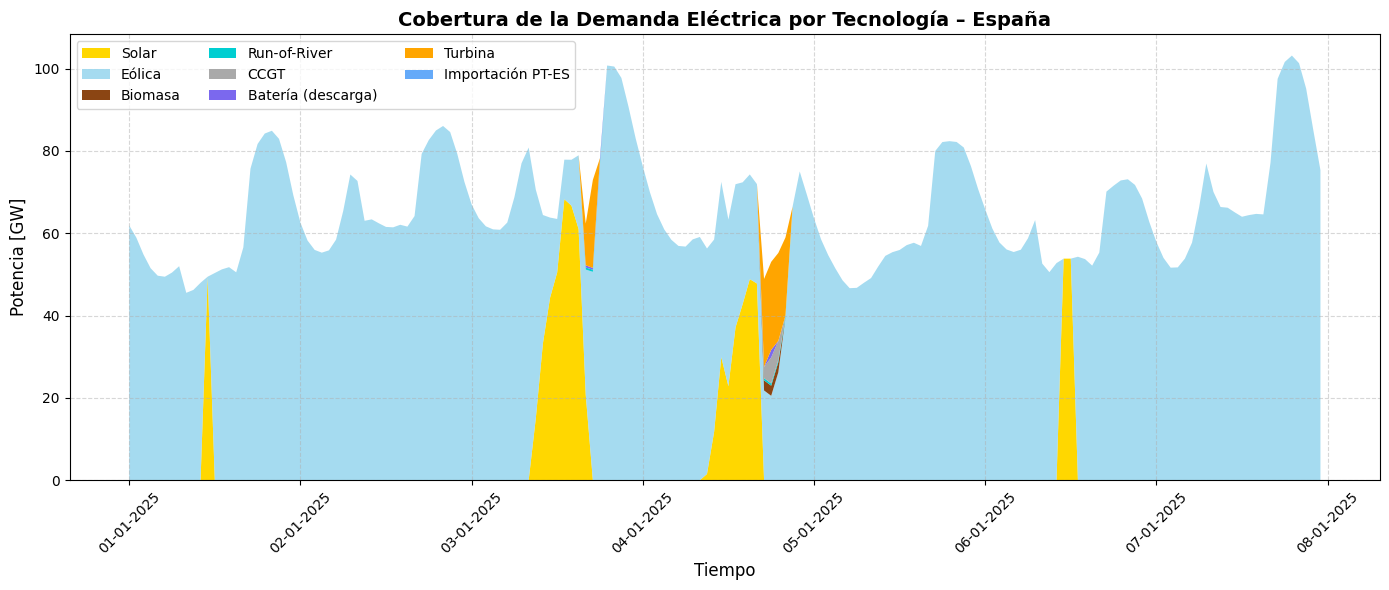

In [314]:
times = network.snapshots
gen = network.generators_t.p
gen_names = gen.columns.str.lower()
renew_map = {
    "ES_Solar":   "es_solar",
    "ES_Eólica":  "es_wind",
    "ES_Biomasa": "es_biomass",
    "ES_Water":   "es_water",
}
renew_series = {}
for label, key in renew_map.items():
    gens = gen.columns[gen_names.str.contains(key)]
    if len(gens) == 0:
        print(f"No se encontraron generadores con '{key}'")
        renew_series[label] = 0.0
    else:
        renew_series[label] = gen[gens].sum(axis=1)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# LINKS UTILIZADOS EN ESPAÑA PARA CUBRIR DEMANDA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
links_car = network.links.static.index.str.lower()
# Link 1 que genera electricidad: CCGT
ccgt_name = [
    n for n in network.links.static.index
    if "es_ccgt" in n.lower()
]
if len(ccgt_name) == 0:
    print("No se encontró ningún link con 'CCGT'")
CCGT = -network.links_t.p1[ccgt_name].sum(axis=1).clip(upper=0)

# Link 2 que genera electricidad: TURBINA
turb_name = [
    n for n in network.links.static.index
    if "es_turbina" in n.lower()
]
if len(turb_name) == 0:
    print("No se encontró ningún link con 'turbina'")
turb = -network.links_t.p1[turb_name].sum(axis=1).clip(upper=0)

# Link 3 que genera electricidad: Importacion PT-ES Eléctricidad
import_es_pt = network.links_t.p1["PT_ES_interconexion_electricidad"].clip(upper=0)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# STORAGE UNITS: BATERÍAS ELECTRICIDAD Y ALMACENAMIENTO DE HIDRÓGENO
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

su_names = network.storage_units.static.index.str.lower()

battery_sus = [n for n in network.storage_units.static.index if "es_electricity_market_battery" in n.lower()]
h2_sus      = [n for n in network.storage_units.static.index if "es_hydrogen_storage" in n.lower()]

# 6) Potencia neta
bat_net = network.storage_units_t.p[battery_sus].sum(axis=1)
h2_net  = network.storage_units_t.p[h2_sus].sum(axis=1)

battery_discharge = bat_net.clip(lower=0)
h2_discharge = h2_net.clip(lower=0)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# DATAFRAME PARA GRÁFICA DE COBERTURA DE DEMANDA EN ESPAÑA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


df_plot = pd.DataFrame({
    "ES_Solar":         renew_series["ES_Solar"]     / 1e3,
    "ES_Eólica":        renew_series["ES_Eólica"]      / 1e3,
    "ES_Biomasa":       renew_series["ES_Biomasa"]   / 1e3,
    "ES_Run-of-River":  renew_series["ES_Water"]     / 1e3,
    "ES_CCGT":          CCGT                      / 1e3,
    "ES_electricity_market_battery":      battery_discharge         / 1e3,
    "ES_turbina":       turb                      / 1e3,
    "PT_ES_interconexion_electricidad": import_es_pt / 1e3,
}, index=times)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# COLORES PARA GRÁFICA Y TECNOLOGÍA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

colors = {
    "ES_Solar":                           "#FFD700",
    "ES_Eólica":                          "#87CFEBBE",
    "ES_Biomasa":                         "#8B4513",
    "ES_Run-of-River":                    "#00CED1",
    "ES_CCGT":                            "#A9A9A9",
    "ES_electricity_market_battery":      "#7B68EE",
    "ES_turbina":                         "#FFA500",
    "PT_ES_interconexion_electricidad":   "#2386F7B2",
}

c = [colors[col] for col in df_plot.columns]

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# PERSONALIZACIÓN DE LA GRÁFICA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

plt.figure(figsize=(14, 6))
plt.stackplot(
    df_plot.index,
    df_plot["ES_Solar"], df_plot["ES_Eólica"], df_plot["ES_Biomasa"], df_plot["ES_Run-of-River"], df_plot["ES_CCGT"], df_plot["ES_electricity_market_battery"], df_plot["ES_turbina"], df_plot["PT_ES_interconexion_electricidad"],
    labels=["Solar","Eólica","Biomasa","Run-of-River","CCGT","Batería (descarga)","Turbina","Importación PT-ES"],
    colors=[colors["ES_Solar"],colors["ES_Eólica"],colors["ES_Biomasa"],colors["ES_Run-of-River"],colors["ES_CCGT"],colors["ES_electricity_market_battery"],colors["ES_turbina"],colors["PT_ES_interconexion_electricidad"],],
    linewidth=0.0,
)
plt.title("Cobertura de la Demanda Eléctrica por Tecnología – España",fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10, ncol=3)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\784795217.py:33: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\784795217.py:41: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\784795217.py:44: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\784795217.py:56: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic`

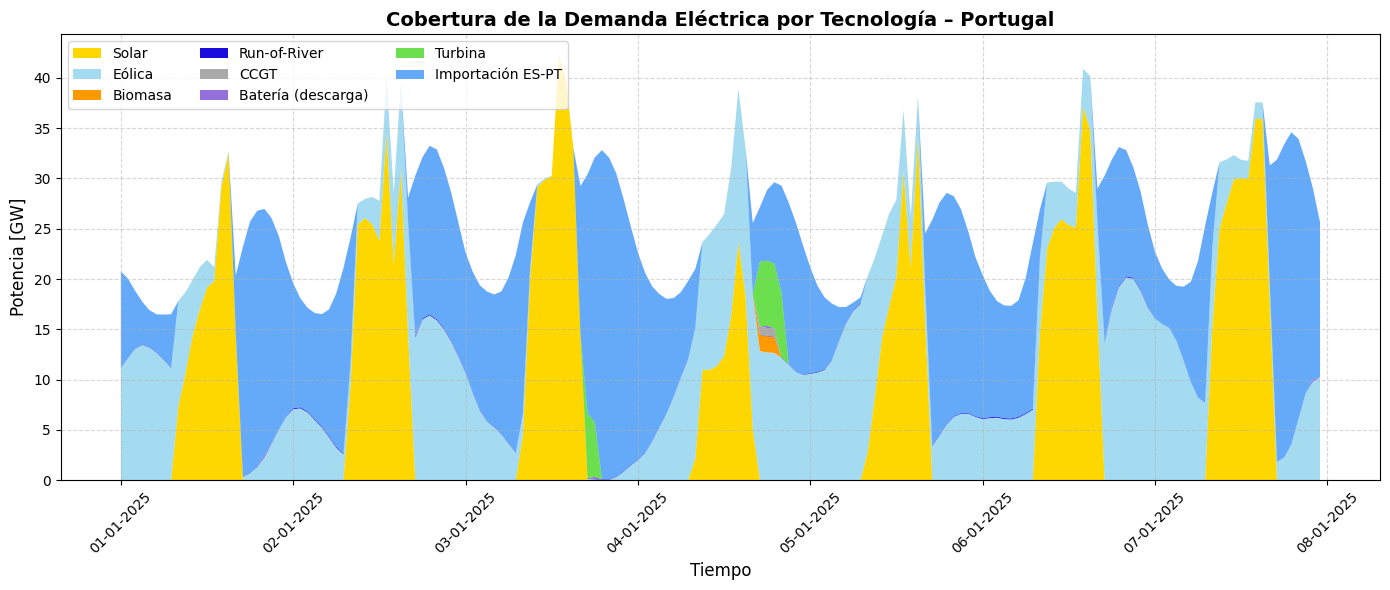

In [315]:
times = network.snapshots
gen_names = gen.columns.str.lower()
gens = gen.columns[gen_names.str.contains(key)]

renew_map = {
    "PT_Solar":   "pt_solar",
    "PT_Eólica":  "pt_wind",
    "PT_Biomasa": "pt_biomass",
    "PT_Water":   "pt_water",
}
 
renew_series = {}

for label, key in renew_map.items():
    gens = gen.columns[gen_names.str.contains(key)]
    if len(gens) == 0:
        print(f"No se encontraron generadores con '{key}'")
        renew_series[label] = 0.0
    else:
        renew_series[label] = gen[gens].sum(axis=1)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# LINKS UTILIZADOS EN PORTUGAL PARA CUBRIR DEMANDA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
links_car = network.links.static.index.str.lower()

# CCGT
ccgt_name = [
    n for n in network.links.static.index
    if "pt_ccgt" in n.lower()
]
if len(ccgt_name) == 0:
    print("No se encontró ningún link con 'CCGT'")
CCGT = -network.links_t.p1[ccgt_name].sum(axis=1).clip(upper=0)

turb_name = [
    n for n in network.links.static.index
    if "pt_turbina" in n.lower()
]
if len(turb_name) == 0:
    print("No se encontró ningún link con 'turbina'")
turb = -network.links_t.p1[turb_name].sum(axis=1).clip(upper=0)

# Importacion ES-PT Eléctricidad
import_es_pt = -network.links_t.p1["ES_PT_interconexion_electricidad"].clip(upper=0)


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# STORAGE UNITS: BATERÍAS ELECTRICIDAD Y ALMACENAMIENTO DE HIDRÓGENO
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

su_names = network.storage_units.static.index.str.lower()

battery_sus = [n for n in network.storage_units.static.index if "pt_electricity_market_battery" in n.lower()]
h2_sus      = [n for n in network.storage_units.static.index if "p_hydrogen_storage" in n.lower()]

bat_net = network.storage_units_t.p[battery_sus].sum(axis=1)
h2_net  = network.storage_units_t.p[h2_sus].sum(axis=1)

battery_discharge = bat_net.clip(lower=0)
h2_discharge = h2_net.clip(lower=0)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# DATAFRAME PARA GRÁFICA DE COBERTURA DE DEMANDA EN PORTUGAL
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

df_plot = pd.DataFrame({
    "PT_Solar":         renew_series["PT_Solar"]     / 1e3,
    "PT_Eólica":        renew_series["PT_Eólica"]      / 1e3,
    "PT_Biomasa":       renew_series["PT_Biomasa"]   / 1e3,
    "PT_Run-of-River":  renew_series["PT_Water"]     / 1e3,
    "PT_CCGT":          CCGT                      / 1e3,
    "PT_electricity_market_battery":      battery_discharge         / 1e3,
    "PT_turbina":       turb                      / 1e3,
    "PT_ES_interconexion_electricidad": import_es_pt / 1e3,
}, index=times)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# COLORES PARA GRÁFICA Y TECNOLOGÍA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

colors = {
    "PT_Solar":                          "#FFD700",
    "PT_Eólica":                         "#87CFEBBE",
    "PT_Biomasa":                        "#FF9900",
    "PT_Run-of-River":                   "#1A0CDF",
    "PT_CCGT":                           "#A9A9A9",
    "PT_electricity_market_battery":     "#9370DB",
    "PT_turbina":                        "#2AD100B0",
    "PT_ES_interconexion_electricidad":  "#2386F7B2",
}

c = [colors[col] for col in df_plot.columns]

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# PERSONALIZACIÓN DE LA GRÁFICA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

plt.figure(figsize=(14, 6))
plt.stackplot(df_plot.index, df_plot["PT_Solar"], df_plot["PT_Eólica"], df_plot["PT_Biomasa"],df_plot["PT_Run-of-River"],df_plot["PT_CCGT"],df_plot["PT_electricity_market_battery"], df_plot["PT_turbina"],df_plot["PT_ES_interconexion_electricidad"],
    labels=["Solar","Eólica","Biomasa","Run-of-River","CCGT","Batería (descarga)","Turbina","Importación ES-PT"],
    colors=[colors["PT_Solar"],colors["PT_Eólica"],colors["PT_Biomasa"],colors["PT_Run-of-River"],colors["PT_CCGT"],colors["PT_electricity_market_battery"],colors["PT_turbina"],colors["PT_ES_interconexion_electricidad"],],
    linewidth=0.0,)
plt.title("Cobertura de la Demanda Eléctrica por Tecnología – Portugal",fontsize=14,fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10, ncol=3)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\3187169371.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\3187169371.py:15: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\3187169371.py:22: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\3187169371.py:36: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more informa

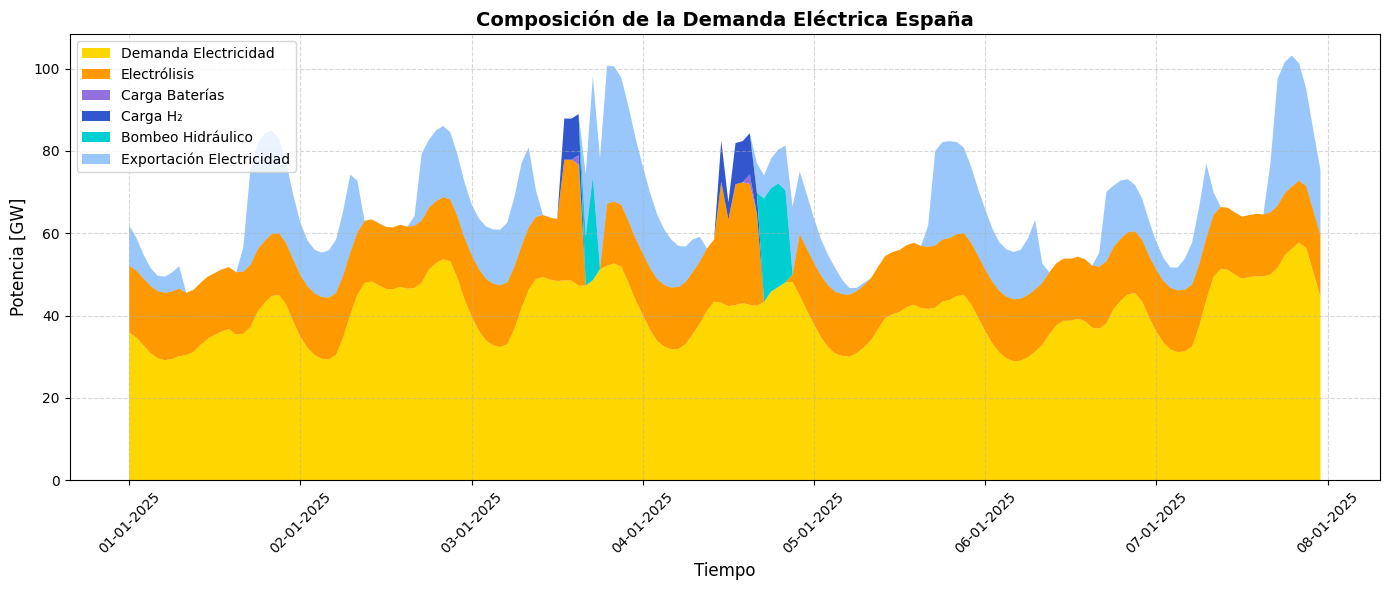

In [316]:
# ----------------------------- DEMANDA NACIONAL -----------------------------
national_electricity_demand = network.loads_t.p_set["ES_demand_2040"] / 1e3   # MW → GW

# ----------------------------- STORAGE UNITS --------------------------------
# En nuevo API: la tabla está en .storage_units.static
su_index = network.storage_units.static.index

# Selección robusta por nombre
battery_sus = [n for n in su_index if "es_electricity_market_battery" in n.lower()]

h2_sus      = [n for n in su_index if "es_hydrogen_storage" in n.lower()]
 
# ------------------------- CARGA DE BATERÍAS / H2 ---------------------------
battery_charge = (
    network.storage_units_t.p[battery_sus]
    .clip(upper=0)               # dejamos solo la carga (valores negativos)
    .sum(axis=1)
    .abs() / 1e3                 # MW → GW
)

h2_charge = (
    network.storage_units_t.p[h2_sus]
    .clip(upper=0)
    .sum(axis=1)
    .abs() / 1e3
)
# ------------------------- BOMBEO HIDRÁULICO --------------------------------
# Nuevo API: nombres en network.links.static.index
link_index = network.links.static.index

pumped_links = [
    l for l in link_index
    if ("es_pump" in l.lower()) or ("es_turbina" in l.lower())
]
pumping_demand = (
    network.links_t.p0[pumped_links]     # p0 positivo = consumo eléctrico
    .clip(lower=0)
    .sum(axis=1) / 1e3                   # MW → GW
)
# --------------------------- ELECTROLIZADORES --------------------------------

electrolyzer_links = [
    l for l in link_index if "es_electrolyzer" in l.lower()
]

electrolyzer_demand = (
    network.links_t.p0[electrolyzer_links]
    .clip(lower=0)
    .sum(axis=1) / 1e3
)

# --------------------------- EXPORTACIONES ELECTRICIDAD  --------------------------------
exportelectricity_links = [
    l for l in link_index if "es_pt_interconexion_electricidad" in l.lower()
]
exportelectricity_demand = (
    network.links_t.p0[exportelectricity_links]
    .clip(lower=0)
    .sum(axis=1) / 1e3
)
# --------------------------- GRÁFICA STACKPLOT -------------------------------
plt.figure(figsize=(14, 6))
plt.stackplot(
     national_electricity_demand.index,
     national_electricity_demand,
     electrolyzer_demand,
     battery_charge,
     h2_charge,
    pumping_demand,
    exportelectricity_demand,
    labels=[
         "Demanda Electricidad",
         "Electrólisis",
         "Carga Baterías",
         "Carga H₂",
         "Bombeo Hidráulico",
        "Exportación Electricidad"
    ],
    colors=[
         "#FFD700",  # Demanda
         "#FF9900",  # Electrólisis
        "#9370DB",  # Carga Baterías
         "#3256CD",  # Carga H2
         "#00CED1",  # Bombeo
        "#2386F776"   # Exportación Electricidad
    ],
    linewidth=0.0,
)

plt.title("Composición de la Demanda Eléctrica España", fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()

# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))

plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\358112589.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\358112589.py:14: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\358112589.py:21: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\358112589.py:35: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information

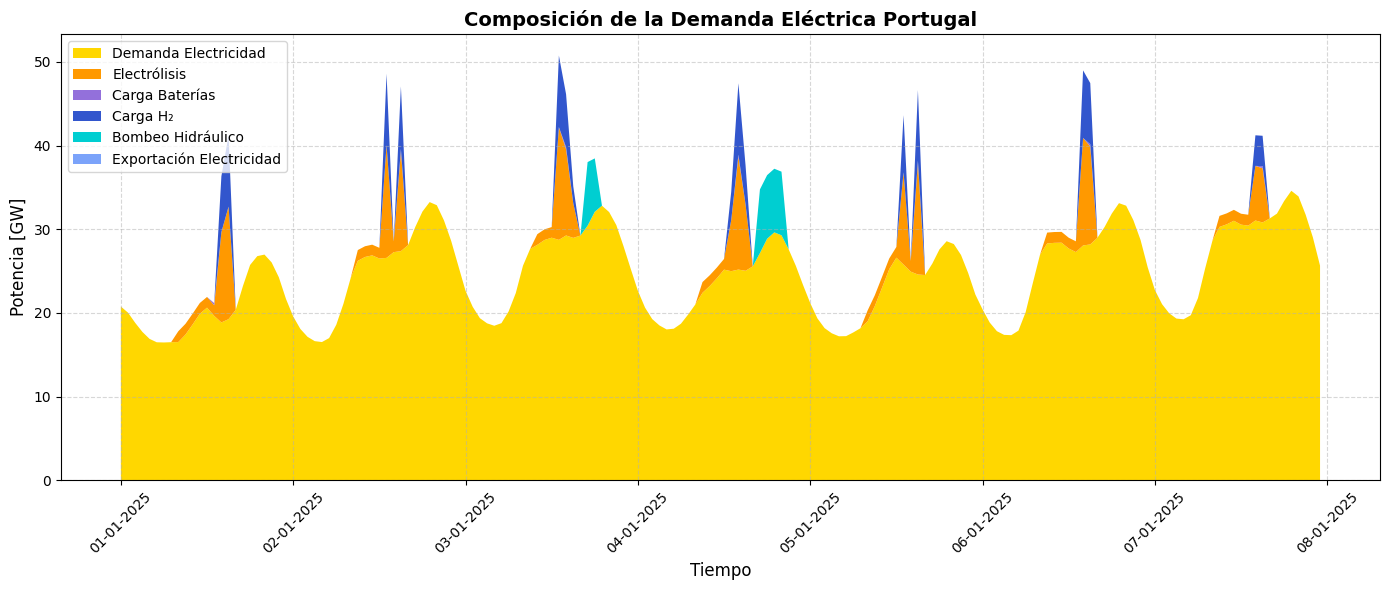

In [317]:
# ----------------------------- DEMANDA NACIONAL -----------------------------
national_electricity_demand = network.loads_t.p_set["PT_demand_2040"] / 1e3   # MW → GW
# ----------------------------- STORAGE UNITS --------------------------------
# En nuevo API: la tabla está en .storage_units.static
su_index = network.storage_units.static.index

# Selección robusta por nombre
battery_sus = [n for n in su_index if "pt_electricity_market_battery" in n.lower()]

h2_sus      = [n for n in su_index if "pt_hydrogen_storage" in n.lower()]

# ------------------------- CARGA DE BATERÍAS / H2 ---------------------------
battery_charge = (
    network.storage_units_t.p[battery_sus]
    .clip(upper=0)               # dejamos solo la carga (valores negativos)
    .sum(axis=1)
    .abs() / 1e3                 # MW → GW
)

h2_charge = (
    network.storage_units_t.p[h2_sus]
    .clip(upper=0)
    .sum(axis=1)
    .abs() / 1e3
)
# ------------------------- BOMBEO HIDRÁULICO --------------------------------
# Nuevo API: nombres en network.links.static.index
link_index = network.links.static.index

pumped_links = [
    l for l in link_index
    if ("pt_pump" in l.lower()) or ("pt_turbina" in l.lower())
]
pumping_demand = (
    network.links_t.p0[pumped_links]     # p0 positivo = consumo eléctrico
    .clip(lower=0)
    .sum(axis=1) / 1e3                   # MW → GW
)
# --------------------------- ELECTROLIZADORES --------------------------------

electrolyzer_links = [
    l for l in link_index if "pt_electrolyzer" in l.lower()
]

electrolyzer_demand = (
    network.links_t.p0[electrolyzer_links]
    .clip(lower=0)
    .sum(axis=1) / 1e3
)

# --------------------------- EXPORTACIONES ELECTRICIDAD  --------------------------------
exportelectricity_links = [
    l for l in link_index if "pt_es_interconexion_electricidad" in l.lower()
]
exportelectricity_demand = (
    network.links_t.p0[exportelectricity_links]
    .clip(lower=0)
    .sum(axis=1) / 1e3
)
# --------------------------- GRÁFICA STACKPLOT -------------------------------
plt.figure(figsize=(14, 6))
plt.stackplot(
     national_electricity_demand.index,
     national_electricity_demand,
     electrolyzer_demand,
     battery_charge,
     h2_charge,
    pumping_demand,
    exportelectricity_demand,
    labels=[
         "Demanda Electricidad",
         "Electrólisis",
         "Carga Baterías",
         "Carga H₂",
         "Bombeo Hidráulico",
        "Exportación Electricidad"
    ],
    colors=[
        "#FFD700",  # Demanda
        "#FF9900",  # Electrólisis
        "#9370DB",  # Carga Baterías
        "#3256CD",  # Carga H2
        "#00CED1",  # Bombeo
        "#2366F799"   # Exportación Electricidad
    ],
    linewidth=0.0,
)

plt.title("Composición de la Demanda Eléctrica Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()

# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))

plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\3482961119.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\3482961119.py:5: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\3482961119.py:8: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



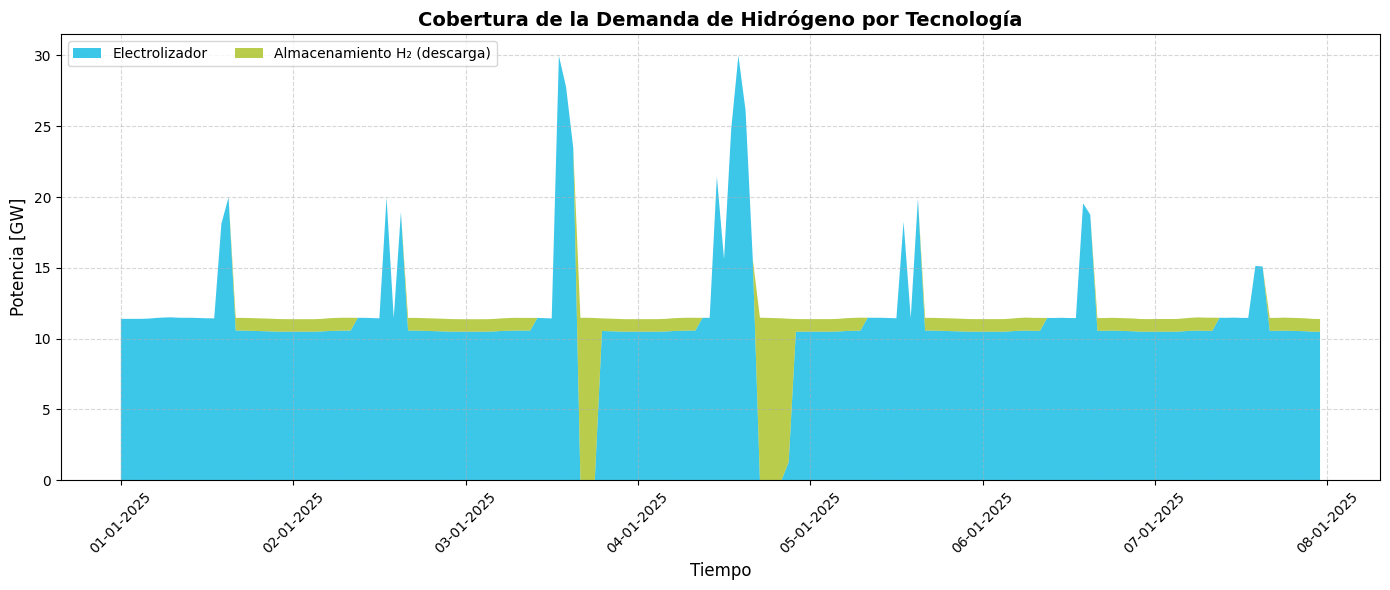

In [318]:

# Índice temporal.... REPASAR.
times = network.snapshots
# ------------------ Electrolizador ----------------------------------------------------------
electrolyzer_cols = [c for c in network.links_t.p1.columns if "electrolyzer" in c.lower()]
electrolyzer = -network.links_t.p1[electrolyzer_cols].clip(upper=0).sum(axis=1) / 1e3  # GW
# ------------------ Almacenamiento H₂ -------------------------------------------------------
h2_sus = [n for n in network.storage_units.static.index if "hydrogen_storage" in n.lower()]
h2_net = network.storage_units_t.p[h2_sus].sum(axis=1)
h2_discharge = h2_net.clip(lower=0) / 1e3  # GW
# ------------------ DataFrame para la gráfica -----------------------------------------------
df_plot = pd.DataFrame({
    "Electrolizador": electrolyzer,
    "Almacenamiento H₂": h2_discharge,
}, index=times)
# ------------------ Colores -----------------------------------------------------------------
colors = {
    "Electrolizador": "#00B5E2C3",
    "Almacenamiento H₂": "#9CB700B3",
}
c = [colors[col] for col in df_plot.columns]

# --------------------------- GRÁFICA STACKPLOT -------------------------------
plt.figure(figsize=(14, 6))

plt.stackplot(
    df_plot.index,
    df_plot["Electrolizador"],
    df_plot["Almacenamiento H₂"],
    labels=[
        "Electrolizador",
        "Almacenamiento H₂ (descarga)"
    ],
    colors=[
        colors["Electrolizador"],
        colors["Almacenamiento H₂"],
    ],
    linewidth=0.0,
)

plt.title(
    "Cobertura de la Demanda de Hidrógeno por Tecnología",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10, ncol=2)

plt.tight_layout()

# Formato del eje X (idéntico al resto de figuras)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))

plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\2520014956.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\2520014956.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



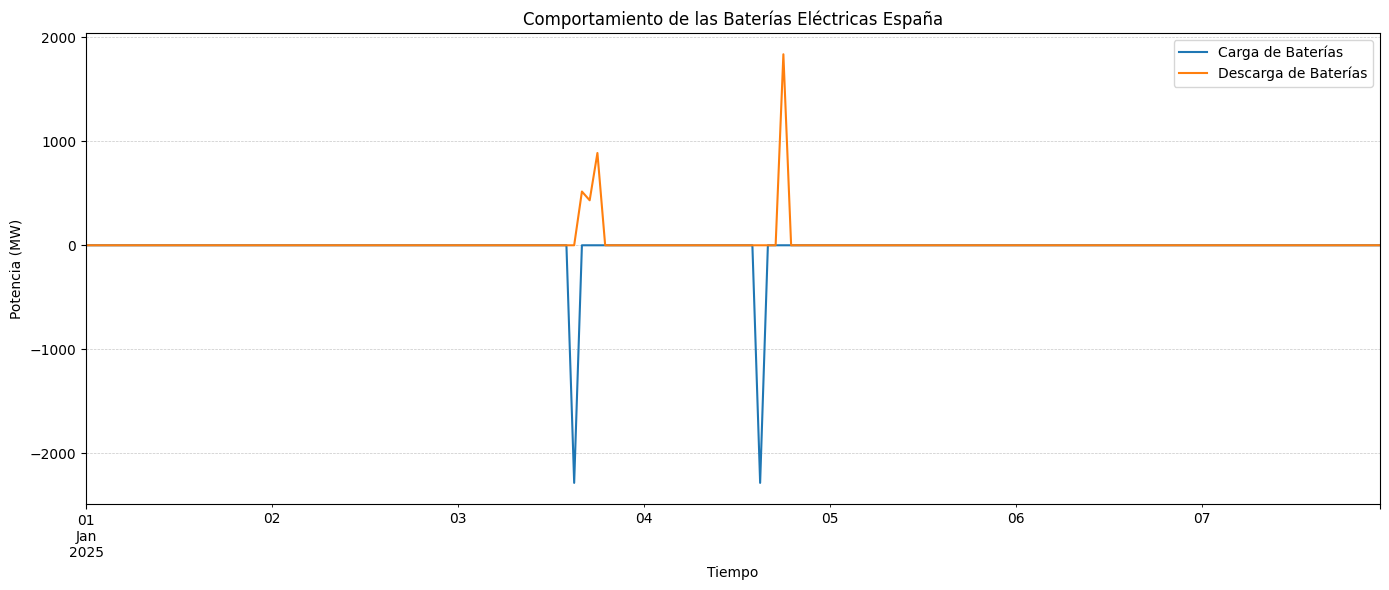

In [319]:
#Grafica de la baterias electricas

#extraemos la serie de carga de las baterias electricas
battery_charge = network.storage_units_t.p["ES_electricity_market_battery"].clip(upper=0)
#extraemos la serie de descarga de las baterias electricas
battery_discharge = network.storage_units_t.p["ES_electricity_market_battery"].clip(lower=0)
#graficamos la carga y descarga de las baterias electricas
plt.figure(figsize=(14, 6))
battery_charge.plot(label="Carga de Baterías", color="tab:blue")
battery_discharge.plot(label="Descarga de Baterías", color="tab:orange")
plt.title("Comportamiento de las Baterías Eléctricas España")
plt.ylabel("Potencia (MW)")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

# OJO

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\2924447946.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\2924447946.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



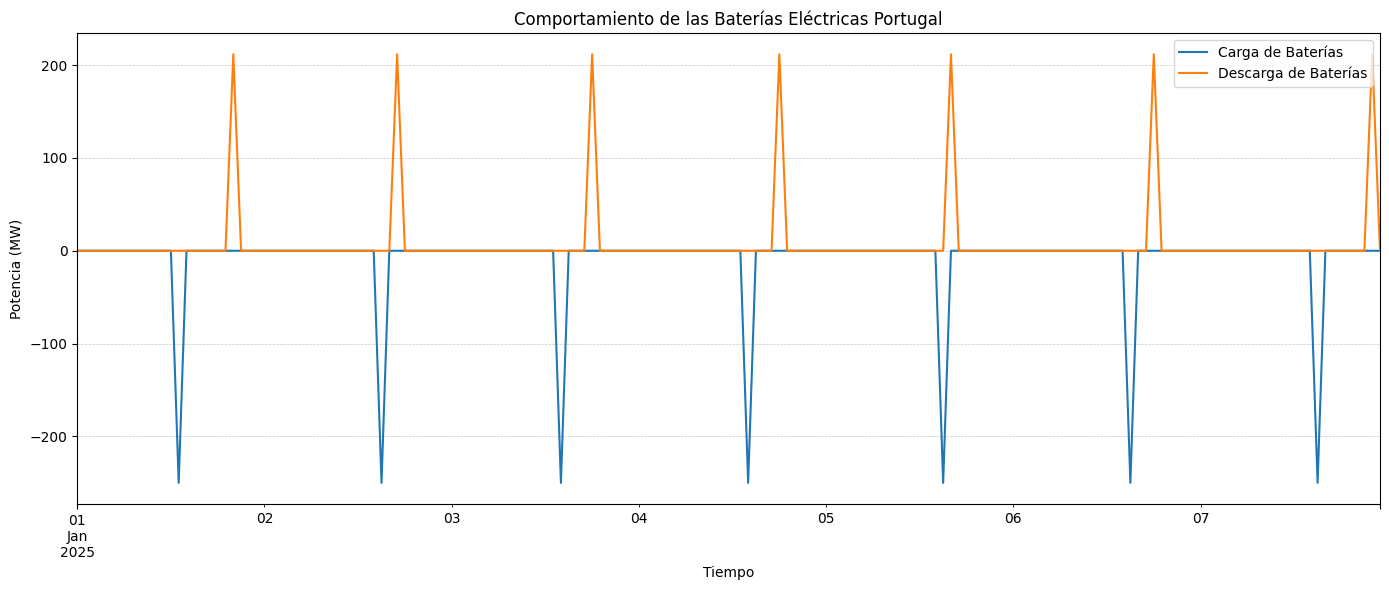

In [320]:
#Grafica de la baterias electricas

#extraemos la serie de carga de las baterias electricas
battery_charge = network.storage_units_t.p["PT_electricity_market_battery"].clip(upper=0)
#extraemos la serie de descarga de las baterias electricas
battery_discharge = network.storage_units_t.p["PT_electricity_market_battery"].clip(lower=0)
#graficamos la carga y descarga de las baterias electricas
plt.figure(figsize=(14, 6))
battery_charge.plot(label="Carga de Baterías", color="tab:blue")
battery_discharge.plot(label="Descarga de Baterías", color="tab:orange")
plt.title("Comportamiento de las Baterías Eléctricas Portugal")
plt.ylabel("Potencia (MW)")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\4015372754.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



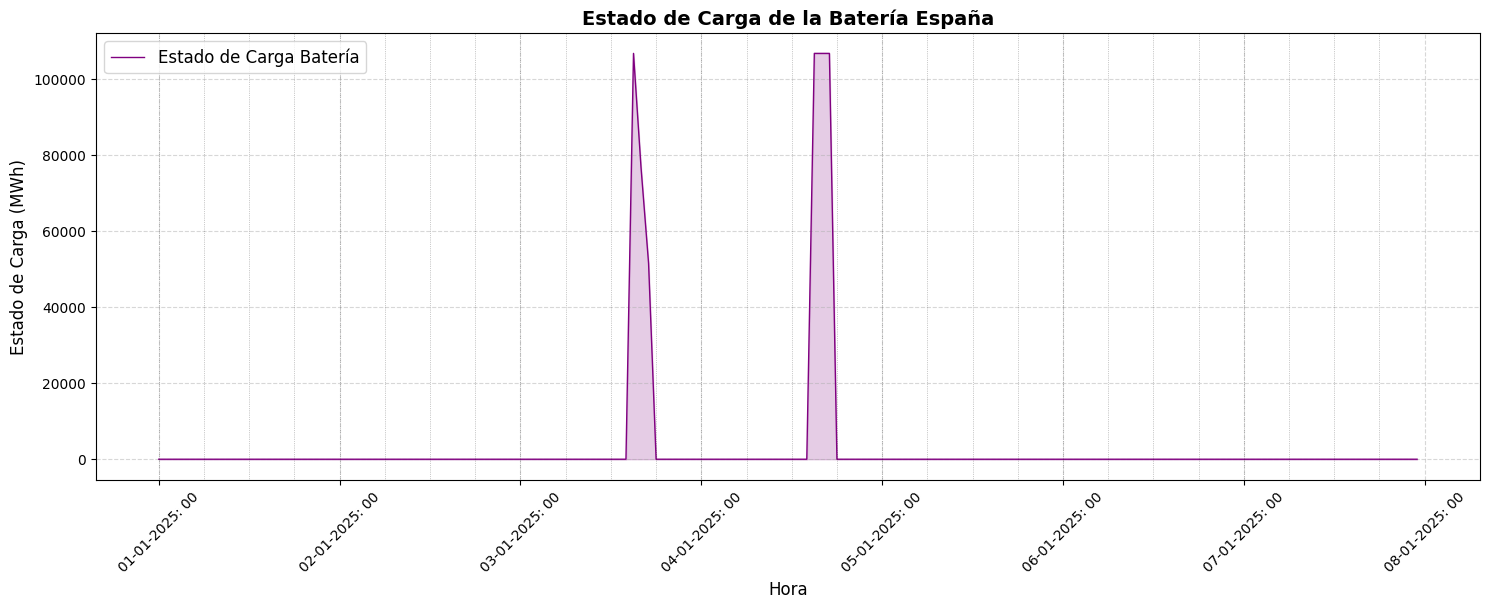

In [321]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["ES_electricity_market_battery"]
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, soc_batt, label="Estado de Carga Batería", color="purple", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="purple", alpha=0.2)    
plt.title("Estado de Carga de la Batería España", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Estado de Carga (MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\2012518425.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



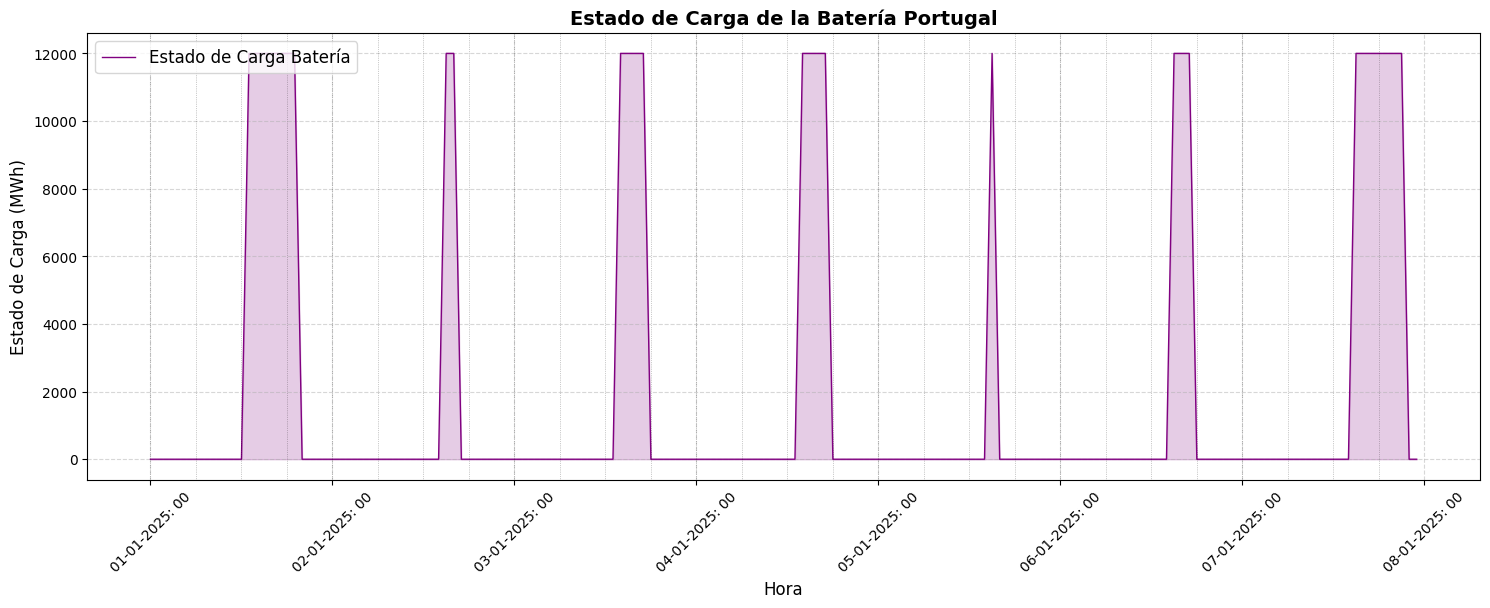

In [322]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["PT_electricity_market_battery"]
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, soc_batt, label="Estado de Carga Batería", color="purple", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="purple", alpha=0.2)    
plt.title("Estado de Carga de la Batería Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Estado de Carga (MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\301106751.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



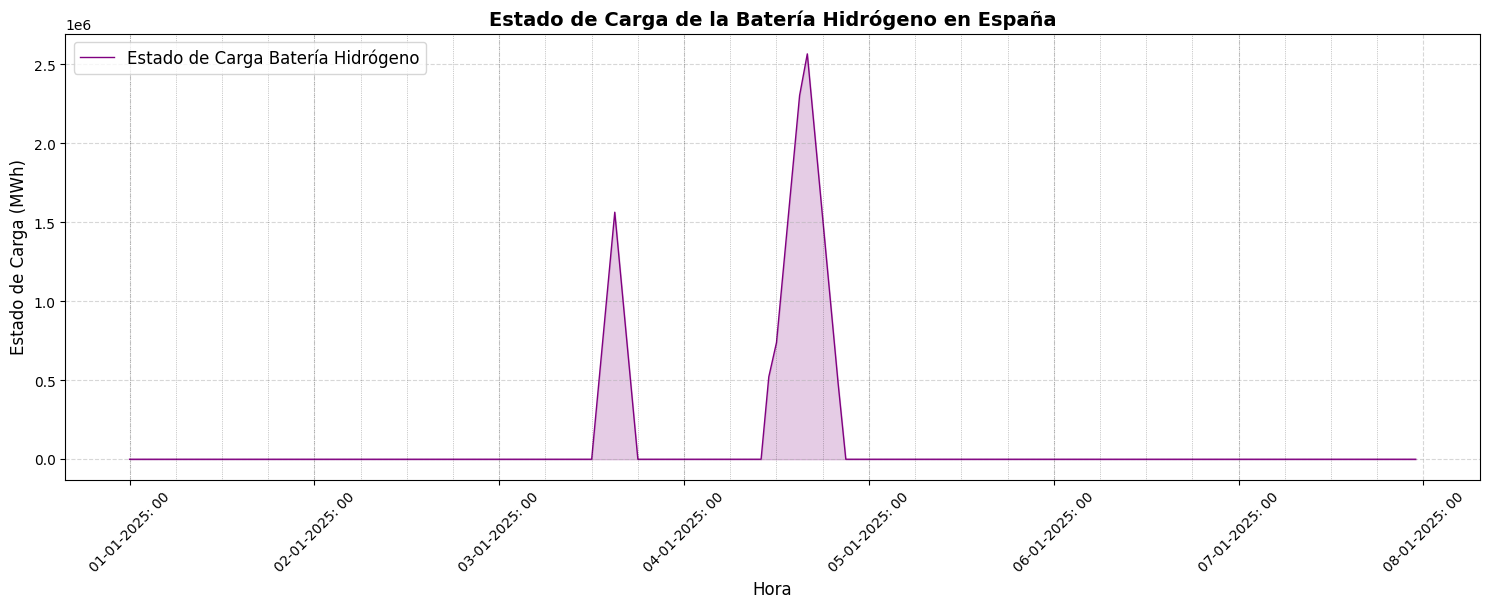

In [323]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["ES_hydrogen_storage"]
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, soc_batt, label="Estado de Carga Batería Hidrógeno", color="purple", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="purple", alpha=0.2)    
plt.title("Estado de Carga de la Batería Hidrógeno en España", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Estado de Carga (MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_21064\2790303606.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



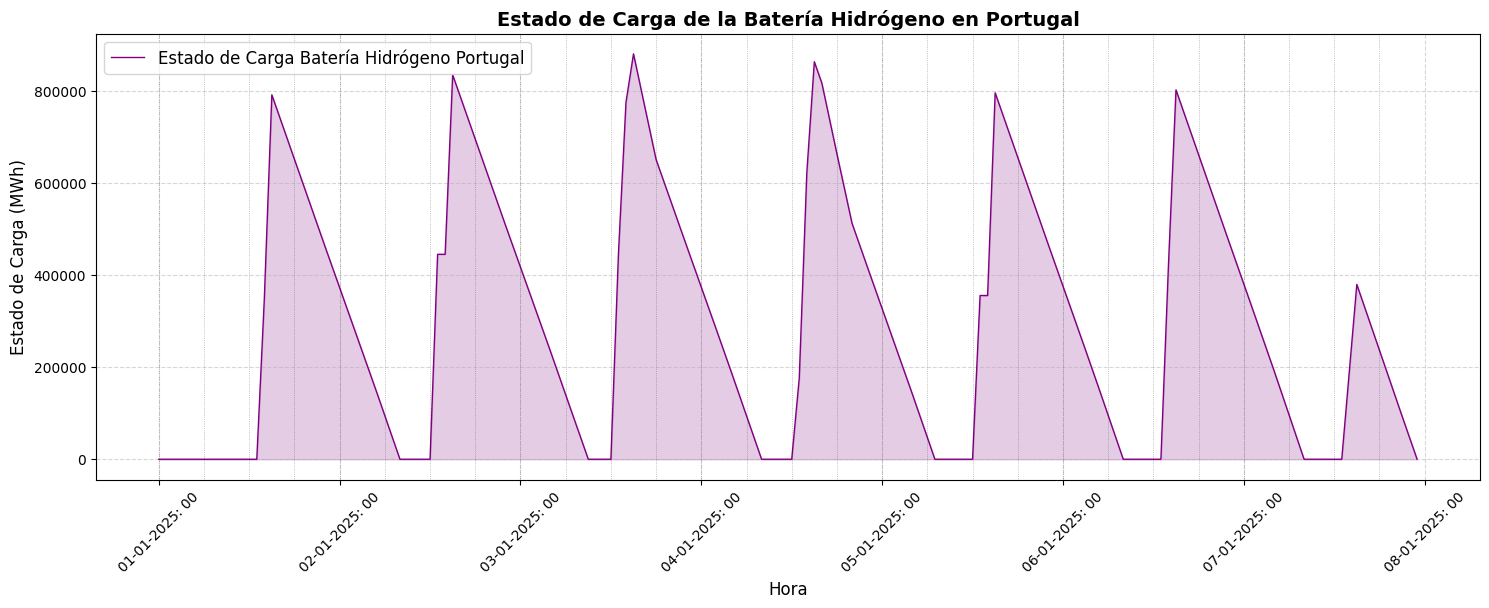

In [324]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["PT_hydrogen_storage"]
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, soc_batt, label="Estado de Carga Batería Hidrógeno Portugal", color="purple", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="purple", alpha=0.2)    
plt.title("Estado de Carga de la Batería Hidrógeno en Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Estado de Carga (MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()